# BoltzGen 旧 12 骨架 × GLP-1 第一轮推理复盘

**分析对象：** 多个彼此隔离的 VHH 骨架管线，以同一份 GLP-1(7–36) 正靶几何进行预训练模型推理。  
**分析边界：** 本 Notebook 只读取 `analysis/` 规范表和 `provenance/` 冻结记录，不重跑模型、不改写原始产物。  
**判读边界：** 结构置信、均方根偏差、预测对齐误差、界面接触和溶剂可接触面积都是计算代理，不是实验亲和力、捕获功能或型态选择性。

Notebook 中的数量、候选颜色、骨架分组和失败条件均由实际表格生成；标题保留“旧 12 骨架”作为本轮项目名称，但代码不会把候选总数写成固定常量，也不会假定每个骨架分析后一定保留两个唯一序列。

## TL;DR

下一单元会在规范表通过完整性检查后，动态生成四类状态：

1. 输入指纹是否一致；
2. 独立骨架管线完成了多少；
3. 原始候选、骨架内去重候选和预算展示候选分别有多少；
4. 有多少候选通过全部默认计算过滤。

“预算展示”与“通过过滤”会始终分开；即使最终目录中有 CIF，也不会据此写成计算合格或实验命中。

In [1]:
# 仅导入表格、绘图和展示库；这里不会导入 BoltzGen、PyTorch 或模型权重。
from __future__ import annotations

import html
import json
import logging
import math
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display


# 关闭 Matplotlib 的字体匹配噪声；字体缺失仍会按列表正常回退。
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


def locate_run_root(start: Path) -> Path:
    """向上寻找同时含 analysis/ 与 provenance/ 的本轮根目录。"""

    resolved = start.resolve()
    for candidate in (resolved, *resolved.parents):
        if (candidate / "analysis").is_dir() and (candidate / "provenance").is_dir():
            return candidate
    raise FileNotFoundError(
        "无法定位本轮目录：从当前工作目录向上没有找到 analysis/ 与 provenance/。"
    )


RUN_ROOT = locate_run_root(Path.cwd())
ANALYSIS_DIR = RUN_ROOT / "analysis"
PROVENANCE_DIR = RUN_ROOT / "provenance"

# 必需文件全部来自分析规范表或冻结 provenance。缺失时立即停止，避免显示半成品。
required_files = {
    "input_manifest": PROVENANCE_DIR / "input_manifest.json",
    "runtime_preflight": PROVENANCE_DIR / "runtime_preflight.json",
    "run_summary": ANALYSIS_DIR / "run_summary.json",
    "validation_report": ANALYSIS_DIR / "validation_report.json",
    "resource_summary": ANALYSIS_DIR / "resource_summary.json",
    "npz_schema": ANALYSIS_DIR / "npz_schema.json",
    "run_manifest": ANALYSIS_DIR / "run_manifest.csv",
    "candidate_metrics": ANALYSIS_DIR / "candidate_metrics.csv",
    "process_funnel": ANALYSIS_DIR / "process_funnel.csv",
    "candidate_filter_results": ANALYSIS_DIR / "candidate_filter_results.csv",
    "filter_summary": ANALYSIS_DIR / "filter_summary.csv",
    "interface_contacts": ANALYSIS_DIR / "interface_contacts_independent.csv",
    "sequence_pairs": ANALYSIS_DIR / "sequence_pairs.csv",
    "stage_timings": ANALYSIS_DIR / "stage_timings.csv",
    "per_scaffold_summary": ANALYSIS_DIR / "per_scaffold_summary.csv",
    "candidate_lineage": ANALYSIS_DIR / "candidate_lineage.csv",
    "output_inventory": ANALYSIS_DIR / "output_inventory.tsv",
}
missing_files = [path for path in required_files.values() if not path.is_file()]
if missing_files:
    relative_missing = [
        path.relative_to(RUN_ROOT).as_posix() if path.is_relative_to(RUN_ROOT) else str(path)
        for path in missing_files
    ]
    raise FileNotFoundError(
        "分析尚未完成，Notebook 拒绝生成结果。缺少：\n- "
        + "\n- ".join(relative_missing)
        + "\n请先完成 scripts/analyze_round1.py，再重新执行本 Notebook。"
    )

# 可选资源采样可能因为监控启动较晚或未启动而不存在；缺失时只显示“未测量”。
optional_resource_samples = ANALYSIS_DIR / "runtime_resource_samples.csv"

with required_files["input_manifest"].open(encoding="utf-8") as handle:
    input_manifest = json.load(handle)
with required_files["runtime_preflight"].open(encoding="utf-8") as handle:
    runtime_preflight = json.load(handle)
with required_files["run_summary"].open(encoding="utf-8") as handle:
    run_summary = json.load(handle)
with required_files["validation_report"].open(encoding="utf-8") as handle:
    validation_report = json.load(handle)
with required_files["resource_summary"].open(encoding="utf-8") as handle:
    resource_summary = json.load(handle)
with required_files["npz_schema"].open(encoding="utf-8") as handle:
    npz_schema = json.load(handle)

run_manifest = pd.read_csv(required_files["run_manifest"])
candidate_metrics = pd.read_csv(required_files["candidate_metrics"])
process_funnel = pd.read_csv(required_files["process_funnel"])
filter_results = pd.read_csv(required_files["candidate_filter_results"])
filter_summary = pd.read_csv(required_files["filter_summary"])
interface_contacts = pd.read_csv(required_files["interface_contacts"])
sequence_pairs = pd.read_csv(required_files["sequence_pairs"])
stage_timings = pd.read_csv(required_files["stage_timings"])
per_scaffold_summary = pd.read_csv(required_files["per_scaffold_summary"])
candidate_lineage = pd.read_csv(required_files["candidate_lineage"])
output_inventory = pd.read_csv(required_files["output_inventory"], sep="\t")
resource_samples = (
    pd.read_csv(optional_resource_samples)
    if optional_resource_samples.is_file() and optional_resource_samples.stat().st_size > 0
    else pd.DataFrame()
)

# 将 CSV 中可能出现的字符串布尔值统一为真正的 bool，避免 "False" 被当作 True。
def parse_bool_series(series: pd.Series) -> pd.Series:
    """稳健解析 CSV 布尔列，同时保留缺失值为 False。"""

    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.fillna("").astype(str).str.strip().str.lower().isin(
        {"true", "1", "yes", "y"}
    )


for frame, columns in [
    (candidate_metrics, ["framework_sequence_unchanged", "pass_all_default_filters", "selected_by_budget", "same_best_sample"]),
    (filter_results, ["passed"]),
    (sequence_pairs, ["same_scaffold"]),
]:
    for column in columns:
        if column in frame.columns:
            frame[column] = parse_bool_series(frame[column])

# 统一中文字体、网格和高分辨率。骨架颜色稍后按实际骨架数动态分配。
plt.rcParams.update(
    {
        "font.sans-serif": [
            "PingFang SC",
            "Hiragino Sans GB",
            "Heiti SC",
            "Arial Unicode MS",
            "DejaVu Sans",
        ],
        "axes.unicode_minus": False,
        "figure.dpi": 125,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#94A3B8",
        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "grid.color": "#E2E8F0",
        "grid.linewidth": 0.8,
    }
)

scaffold_order = (
    run_manifest.sort_values("selection_rank")["scaffold_id"].astype(str).tolist()
)
scaffold_count = len(scaffold_order)
color_map = plt.get_cmap("turbo", max(scaffold_count, 1))
scaffold_colors = {
    scaffold_id: color_map(index)
    for index, scaffold_id in enumerate(scaffold_order)
}

print(f"本轮根目录：{RUN_ROOT}")
print(f"已载入规范候选：{len(candidate_metrics)} 条")
print(f"已载入独立骨架管线：{len(run_manifest)} 条")
print("模型推理：未触发；本 Notebook 只读取分析结果。")

本轮根目录：$PROJECT_ROOT/data/boltzgen_data/boltzgen_round1_old12_glp1_20260819
已载入规范候选：24 条
已载入独立骨架管线：12 条
模型推理：未触发；本 Notebook 只读取分析结果。


## Context & Methods

### 数据粒度与判定规则

- `run_manifest.csv`：一行是一个独立骨架管线。
- `candidate_metrics.csv`：一行是骨架内序列去重后的一个候选。
- `candidate_filter_results.csv`：一行是“候选 × 一个过滤条件”。
- `interface_contacts_independent.csv`：一行是“候选 × 一个指定热点残基”。
- `sequence_pairs.csv`：一行是一对候选，包括对角线和上三角组合。

官方热点字段表示覆盖比例，而不是接触数。若指定热点集合为 \(B\)，设计残基集合为 \(D\)，则：

\[
H_i(r)=\frac{1}{|B|}\sum_{b\in B}
\mathbf{1}\left[\min_{d\in D}\lVert c_b-c_d\rVert_2<r\right]
\]

逐项通过数与整体通过分别为：

\[
C_i=\sum_f \mathbf{1}(P_{if}),\qquad
P_i=\bigwedge_f P_{if}
\]

`quality_score_within_scaffold_only` 只是骨架内相对排名映射，不能跨骨架比较，也不是结合概率。

In [2]:
# 验证规范表的列、主键和跨表覆盖率。这里的断言属于报告验收条件，
# 一旦失败就停止后续结论，防止 join 丢行或重复行被图表静默掩盖。
required_columns = {
    "run_manifest": {
        "selection_rank", "scaffold_id", "pdb_code", "status", "requested_designs",
        "raw_design_pairs", "inverse_folded_pairs", "fold_npz", "refold_cif",
        "analyzed_rows", "ranked_unique_rows", "execute_seconds",
    },
    "candidate_metrics": {
        "candidate_id", "candidate_label", "scaffold_id", "scaffold_pdb_code", "scaffold_selection_rank",
        "local_candidate_index", "designed_sequence", "designed_chain_sequence",
        "cdr1_sequence", "cdr2_sequence", "cdr3_sequence", "framework_sequence",
        "framework_sequence_unchanged",
        "filter_rmsd_a", "filter_rmsd_design_a",
        "bb_target_aligned_rmsd_design_a", "design_to_target_iptm", "design_ptm",
        "design_ipsae_min", "min_design_to_target_pae_a",
        "prerefold_hotspot_coverage_fraction_lt8a",
        "independent_hotspot_coverage_heavy_lt8a", "independent_hotspot_coverage_ca_lt8a",
        "his7_min_heavy_atom_distance_a", "ala8_min_heavy_atom_distance_a",
        "target_delta_sasa_refolded_a2", "geometric_hbond_count_refolded",
        "charged_atom_pair_count_refolded",
        "pass_all_default_filters", "selected_by_budget",
        "computed_filter_pass_count", "computed_filter_total", "failed_filters_cn",
        "final_rank_within_scaffold", "same_best_sample",
    },
    "filter_results": {
        "candidate_id", "scaffold_id", "filter_order", "filter_label_cn",
        "observed_value", "operator", "threshold", "unit", "passed",
    },
    "interface_contacts": {
        "candidate_id", "scaffold_id", "hotspot_biological_name",
        "min_heavy_atom_distance_a", "min_ca_distance_a",
    },
    "sequence_pairs": {
        "candidate_id_a", "candidate_id_b", "same_scaffold",
        "design_sequence_identity", "full_vhh_sequence_identity",
        "framework_sequence_identity", "cdr3_sequence_identity",
    },
}
frames = {
    "run_manifest": run_manifest,
    "candidate_metrics": candidate_metrics,
    "filter_results": filter_results,
    "interface_contacts": interface_contacts,
    "sequence_pairs": sequence_pairs,
}
for name, columns in required_columns.items():
    missing = sorted(columns - set(frames[name].columns))
    assert not missing, f"{name} 缺少必需列：{missing}"

expected_scaffolds = int(input_manifest["scaffold_population"]["count"])
expected_requested = int(input_manifest["generation_budget"]["requested_total_designs"])
designs_per_scaffold = int(input_manifest["generation_budget"]["designs_per_scaffold"])

assert len(run_manifest) == expected_scaffolds, (
    f"管线数与 provenance 不一致：表中 {len(run_manifest)}，清单 {expected_scaffolds}。"
)
assert run_manifest["scaffold_id"].nunique() == len(run_manifest), "run_manifest 的 scaffold_id 不唯一。"
assert candidate_metrics["candidate_id"].nunique() == len(candidate_metrics), "候选 ID 不唯一。"
assert (run_manifest["requested_designs"] == designs_per_scaffold).all(), (
    "至少一个骨架的请求数与冻结 generation_budget 不一致。"
)

candidate_ids = set(candidate_metrics["candidate_id"].astype(str))
assert set(filter_results["candidate_id"].astype(str)) == candidate_ids, "过滤表候选覆盖不完整。"
assert set(interface_contacts["candidate_id"].astype(str)) == candidate_ids, "热点表候选覆盖不完整。"
assert set(candidate_lineage["candidate_id"].astype(str)) == candidate_ids, "谱系表候选覆盖不完整。"
assert set(sequence_pairs["candidate_id_a"].astype(str)).issubset(candidate_ids)
assert set(sequence_pairs["candidate_id_b"].astype(str)).issubset(candidate_ids)

filter_rows_per_candidate = filter_results.groupby("candidate_id").size()
assert filter_rows_per_candidate.nunique() == 1, "不同候选的有效过滤条件数不一致。"
assert candidate_metrics["framework_sequence_unchanged"].all(), "存在非设计框架位置被改变的候选。"
assert candidate_metrics["same_best_sample"].all(), "Analysis 与 CIF writer 选择的折叠样本不一致。"

# 读取 analyze_round1.py 已完成的阻断性验证；不在 Notebook 中把失败项降级为警告。
failed_validation_checks = validation_report.get("failed_checks", [])
assert not failed_validation_checks, (
    "analysis/validation_report.json 存在阻断项：" + ", ".join(failed_validation_checks)
)

validation_table = pd.DataFrame(
    [
        {"检查": name, "状态": "通过" if bool(passed) else "失败"}
        for name, passed in validation_report.get("checks", {}).items()
    ]
)
display(validation_table.style.hide(axis="index"))

检查,状态
twelve_unique_scaffolds,通过
all_tasks_pipeline_complete,通过
each_scaffold_has_two_ids_at_every_pre_ranking_stage,通过
each_scaffold_has_exact_budget_one_contract,通过
twenty_four_raw_design_pairs,通过
twenty_four_inverse_fold_pairs,通过
twenty_four_fold_npz,通过
twenty_four_refold_cif,通过
twenty_four_analyzed_rows,通过
candidate_ids_unique_after_per_scaffold_dedup,通过


In [3]:
# 由当前规范表动态生成摘要。工程完成、数据完整与科学过滤是三种不同状态。
completed_tasks = int((run_manifest["status"] == "PIPELINE_COMPLETE").sum())
raw_pairs = int(run_manifest["raw_design_pairs"].sum())
unique_candidates = len(candidate_metrics)
survivors = int(candidate_metrics["pass_all_default_filters"].sum())
budget_candidates = int(candidate_metrics["selected_by_budget"].sum())

summary_markdown = f"""
### 本轮状态

- **输入范围：** {expected_scaffolds} 个冻结骨架；每骨架请求 {designs_per_scaffold} 个原始候选；清单请求总数 {expected_requested}。
- **工程运行：** {completed_tasks}/{len(run_manifest)} 个独立管线状态为 `PIPELINE_COMPLETE`。
- **原始产物：** {raw_pairs}/{expected_requested} 个原始设计 CIF+NPZ 配对。
- **骨架内去重后：** {unique_candidates} 个唯一候选；该数字可以小于原始请求数。
- **默认计算过滤：** {survivors}/{unique_candidates} 个候选通过全部有效过滤条件。
- **预算展示目录：** {budget_candidates} 个候选；它们不自动等于过滤幸存者。
- **数据验证：** `{validation_report['assessment']}`，阻断项 {len(failed_validation_checks)} 个。

以上仅说明本轮工程和计算筛选状态，不构成结合、亲和力、实验命中或 GLP-1 型态选择性结论。
"""
display(Markdown(summary_markdown))


### 本轮状态

- **输入范围：** 12 个冻结骨架；每骨架请求 2 个原始候选；清单请求总数 24。
- **工程运行：** 12/12 个独立管线状态为 `PIPELINE_COMPLETE`。
- **原始产物：** 24/24 个原始设计 CIF+NPZ 配对。
- **骨架内去重后：** 24 个唯一候选；该数字可以小于原始请求数。
- **默认计算过滤：** 0/24 个候选通过全部有效过滤条件。
- **预算展示目录：** 12 个候选；它们不自动等于过滤幸存者。
- **数据验证：** `READY_TO_SHARE_WITH_SCIENTIFIC_CAVEATS`，阻断项 0 个。

以上仅说明本轮工程和计算筛选状态，不构成结合、亲和力、实验命中或 GLP-1 型态选择性结论。


## Data

### 1. 输入指纹与骨架范围

这一节只读取冻结的 `provenance/input_manifest.json`。目标 SHA-256、目标序列、热点生物学身份、骨架设计规格 SHA-256 和模型资产信息用于确认各独立管线确实属于同一轮计算。

In [4]:
# 汇总目标与运行设置。哈希只显示前 16 位便于阅读，完整值仍保留在 provenance。
target = input_manifest["target"]
budget = input_manifest["generation_budget"]
compute = input_manifest["compute_profile"]
input_fingerprint = pd.DataFrame(
    [
        ("campaign_id", input_manifest["campaign_id"]),
        ("执行语义", input_manifest["execution_semantics"]),
        ("正靶名称", target["name"]),
        ("正靶角色", target["role"]),
        ("正靶序列", target["sequence"]),
        ("正靶 SHA-256", target["sha256"]),
        ("热点", "、".join(target["binding_hint_biological_identity"])),
        ("热点 label_seq_id", ", ".join(map(str, target["binding_hint_label_seq_id"]))),
        ("C 端酰胺原子级验证", target["terminal_amide_atomically_verified"]),
        ("骨架数", input_manifest["scaffold_population"]["count"]),
        ("每骨架请求数", budget["designs_per_scaffold"]),
        ("复折叠样本/候选", compute["folding_samples_per_candidate"]),
        ("复折叠采样步数", compute["folding_sampling_steps"]),
        ("recycling 次数", compute["recycling_steps"]),
        ("数值精度", compute["precision"]),
        ("MPS 可用", runtime_preflight.get("mps_available", "未记录")),
        ("PyTorch", runtime_preflight.get("torch", "未记录")),
    ],
    columns=["字段", "冻结值"],
)
display(input_fingerprint.style.hide(axis="index"))

scaffold_rows = []
for record in input_manifest["scaffold_population"]["records"]:
    scaffold_rows.append(
        {
            "筛选序号": record["selection_rank"],
            "骨架ID": record["candidate_id"],
            "PDB": record["pdb_code"],
            "角色": record["role"],
            "框架簇": record["framework_cluster_id"],
            "分辨率 Å": record["resolution_a"],
            "R-free": record["r_free"],
            "CDR1/2/3长度": f"{record['cdr1_length_aa']}/{record['cdr2_length_aa']}/{record['cdr3_length_aa']}",
            "设计规格SHA前16位": record["design_spec_sha256"][:16],
        }
    )
scaffold_table = pd.DataFrame(scaffold_rows).sort_values("筛选序号")
display(scaffold_table.style.hide(axis="index").format({"分辨率 Å": "{:.2f}", "R-free": "{:.4f}"}))

字段,冻结值
campaign_id,boltzgen_round1_old12_glp1_20260819
执行语义,pretrained_inference_candidate_generation_not_weight_training
正靶名称,GLP-1(7-36) receptor-bound geometry from PDB 6X18
正靶角色,positive_target_geometry_only
正靶序列,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR
正靶 SHA-256,11b82b2633793e6799f1d56c19a88fd52828bec5d26d9366801753dfa72d2d53
热点,His7、Ala8
热点 label_seq_id,"1, 2"
C 端酰胺原子级验证,False
骨架数,12


筛选序号,骨架ID,PDB,角色,框架簇,分辨率 Å,R-free,CDR1/2/3长度,设计规格SHA前16位
1,pdb_00007xl0-A,7XL0,PRIMARY,FWC0109,1.70,0.1963,8/7/15,c1c3c9927e2d8e70
2,pdb_00006apo-A,6APO,PRIMARY,FWC0077,1.17,0.1728,8/7/11,e63308c56012e623
3,pdb_00008v9x-A,8V9X,PRIMARY,FWC0211,1.55,0.2181,8/7/7,d719590a242990e4
4,pdb_00006xxo-A,6XXO,PRIMARY,FWC0115,1.50,0.1832,8/8/17,eab4ed2951e40781
5,pdb_00005l21-B,5L21,PRIMARY,FWC0060,1.68,0.2050,12/10/5,67fdc8994929a263
6,pdb_00008fq7-A,8FQ7,PRIMARY,FWC0180,1.40,0.2108,8/8/11,34739cb5cc52af1b
7,pdb_00008e2n-B,8E2N,PRIMARY,FWC0168,1.10,0.2126,8/11/17,c1c17ad2bf141471
8,pdb_00006xym-A,6XYM,PRIMARY,FWC0117,1.20,0.1982,8/19/19,7ca267ca90835808
9,pdb_00008im0-B,8IM0,PRIMARY,FWC0191,1.31,0.1896,8/7/15,2e5b0a65112d3c82
10,pdb_00003tpk-A,3TPK,PRIMARY,FWC0017,1.30,0.1761,8/8/14,9a3737b59f7f3919


### 2. 独立管线与候选谱系

每个骨架在独立目录中完成设计和过滤，之后才在分析层合并。这样可避免 v0.3.2 按 `designed_sequence` 对整个目录去重时，误删“CDR 拼接序列相同但框架不同”的候选。

In [5]:
# 展示每个骨架的真实阶段数量，不假定分析后仍保留固定数量的候选。
run_view_columns = [
    "selection_rank", "pdb_code", "role", "status", "requested_designs",
    "raw_design_pairs", "inverse_folded_pairs", "fold_npz", "refold_cif",
    "analyzed_rows", "ranked_unique_rows", "execute_seconds",
]
run_view = run_manifest[run_view_columns].sort_values("selection_rank").rename(
    columns={
        "selection_rank": "序号",
        "pdb_code": "PDB",
        "role": "角色",
        "status": "状态",
        "requested_designs": "请求",
        "raw_design_pairs": "原始配对",
        "inverse_folded_pairs": "逆折叠配对",
        "fold_npz": "fold NPZ",
        "refold_cif": "refold CIF",
        "analyzed_rows": "分析行",
        "ranked_unique_rows": "骨架内唯一",
        "execute_seconds": "模型管线秒",
    }
)
display(run_view.style.hide(axis="index").format({"模型管线秒": "{:.1f}"}))

# 谱系表应保证每个唯一候选拥有同一组产物角色；角色集合完全由实际表格推导。
lineage_counts = (
    candidate_lineage.groupby(["candidate_id", "scaffold_id"], as_index=False)
    .agg(产物数=("artifact_role", "count"), 总字节=("size_bytes", "sum"))
)
lineage_role_count = candidate_lineage["artifact_role"].nunique()
assert (lineage_counts["产物数"] == lineage_role_count).all(), "候选谱系的产物角色不完整。"
display(
    lineage_counts.head(min(12, len(lineage_counts))).style.hide(axis="index").format(
        {"总字节": lambda value: f"{value / 1024**2:.2f} MiB"}
    )
)
print(f"每个唯一候选应有 {lineage_role_count} 种谱系产物；上表仅展示前 {min(12, len(lineage_counts))} 行。")

序号,PDB,角色,状态,请求,原始配对,逆折叠配对,fold NPZ,refold CIF,分析行,骨架内唯一,模型管线秒
1,7XL0,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,166.9
2,6APO,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,157.7
3,8V9X,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,154.2
4,6XXO,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,162.7
5,5L21,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,156.8
6,8FQ7,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,157.7
7,8E2N,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,164.5
8,6XYM,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,176.0
9,8IM0,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,160.3
10,3TPK,PRIMARY,PIPELINE_COMPLETE,2,2,2,2,2,2,2,159.7


candidate_id,scaffold_id,产物数,总字节
01_pdb_00007xl0-A_0,pdb_00007xl0-A,6,0.32 MiB
01_pdb_00007xl0-A_1,pdb_00007xl0-A,6,0.32 MiB
02_pdb_00006apo-A_0,pdb_00006apo-A,6,0.32 MiB
02_pdb_00006apo-A_1,pdb_00006apo-A,6,0.32 MiB
03_pdb_00008v9x-A_0,pdb_00008v9x-A,6,0.30 MiB
03_pdb_00008v9x-A_1,pdb_00008v9x-A,6,0.30 MiB
04_pdb_00006xxo-A_0,pdb_00006xxo-A,6,0.33 MiB
04_pdb_00006xxo-A_1,pdb_00006xxo-A,6,0.33 MiB
05_pdb_00005l21-B_0,pdb_00005l21-B,6,0.32 MiB
05_pdb_00005l21-B_1,pdb_00005l21-B,6,0.32 MiB


每个唯一候选应有 6 种谱系产物；上表仅展示前 12 行。


## Results

### 3. 全流程漏斗

漏斗分开显示骨架数量和候选数量。最后两步不是严格的父子漏斗：预算目录可能在没有任何候选通过全部过滤时仍保留相对排序候选。

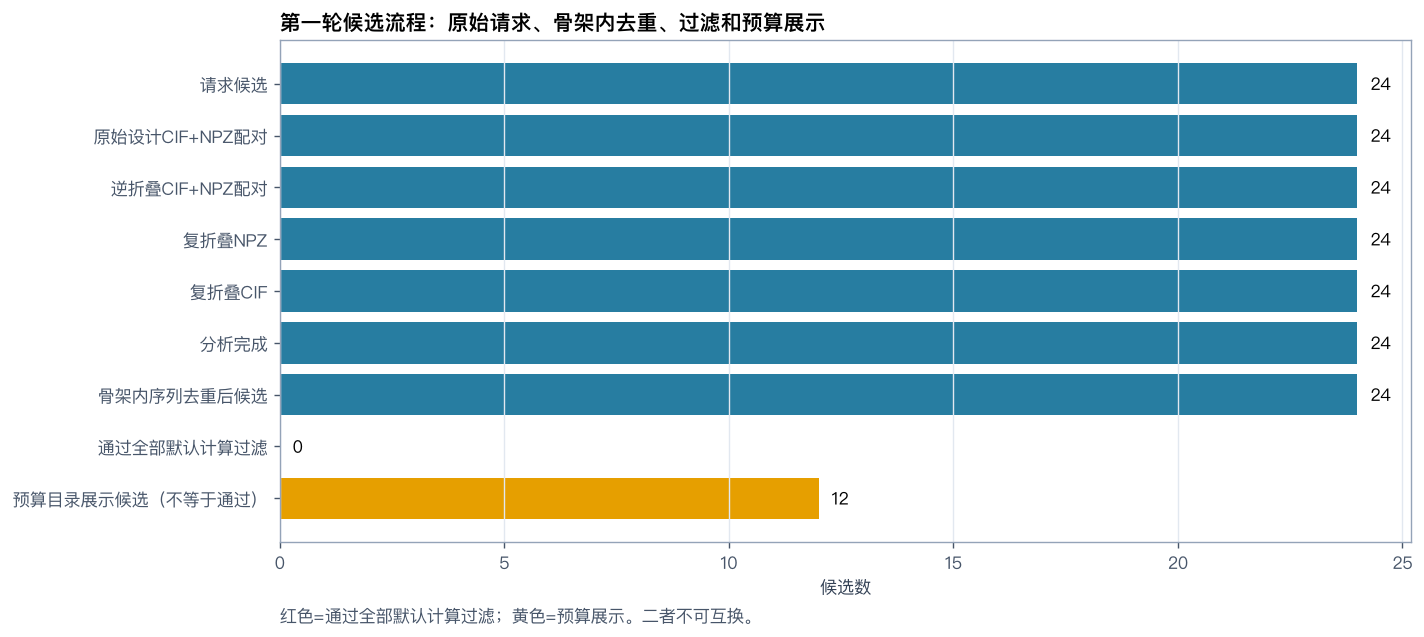

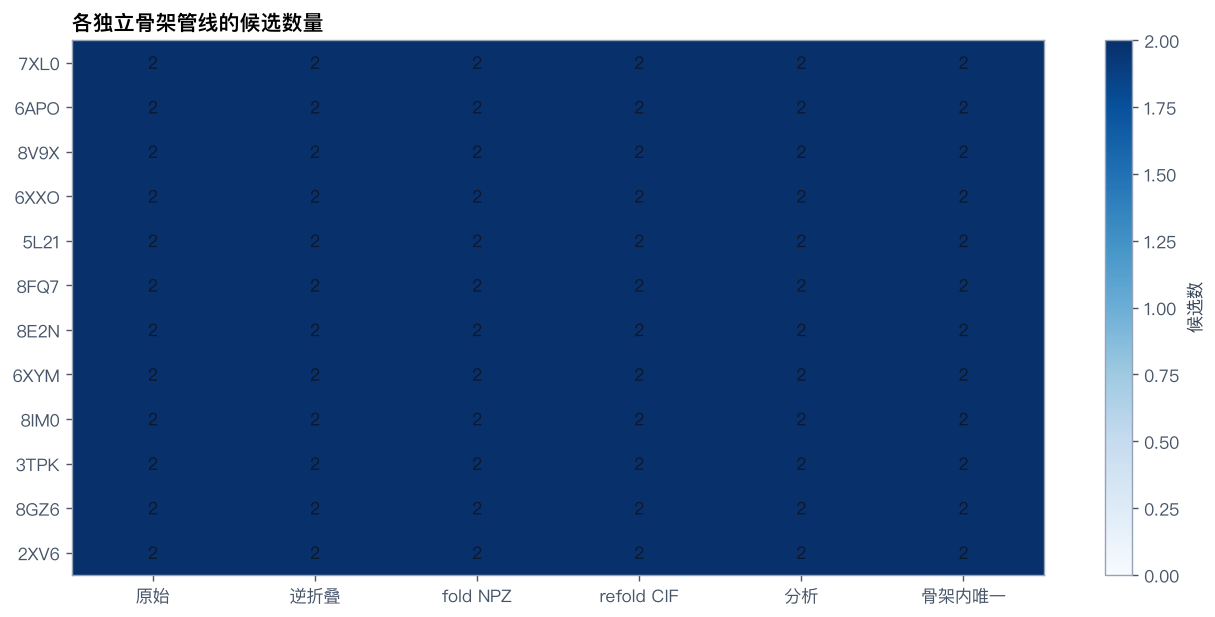

In [6]:
# 使用横向条形图而不是狭窄漏斗形状，避免后段标签被遮挡。
candidate_funnel = process_funnel[process_funnel["unit"] == "candidate"].sort_values("order")
stage_colors = [
    "#C75B4B" if key == "pass_filters" else
    "#E69F00" if key == "selected_budget" else
    "#277DA1"
    for key in candidate_funnel["stage_key"]
]
fig, ax = plt.subplots(figsize=(11.5, max(5.2, 0.55 * len(candidate_funnel))))
bars = ax.barh(candidate_funnel["stage_label_cn"], candidate_funnel["count"], color=stage_colors)
ax.invert_yaxis()
ax.set_xlabel("候选数")
ax.set_title("第一轮候选流程：原始请求、骨架内去重、过滤和预算展示", loc="left")
ax.grid(axis="x")
for bar, value in zip(bars, candidate_funnel["count"], strict=True):
    ax.text(value + max(candidate_funnel["count"].max() * 0.012, 0.1), bar.get_y() + bar.get_height()/2, f"{int(value)}", va="center")
ax.text(
    0.0, -0.16,
    "红色=通过全部默认计算过滤；黄色=预算展示。二者不可互换。",
    transform=ax.transAxes, color="#475569"
)
plt.tight_layout()
plt.show()

# 再以骨架为行显示阶段完整性；每个单元格是该骨架实际候选数。
stage_columns = [
    "raw_design_pairs", "inverse_folded_pairs", "fold_npz", "refold_cif",
    "analyzed_rows", "ranked_unique_rows",
]
stage_labels = ["原始", "逆折叠", "fold NPZ", "refold CIF", "分析", "骨架内唯一"]
stage_matrix = run_manifest.sort_values("selection_rank")[stage_columns].to_numpy(dtype=float)
fig_height = max(5.0, 0.42 * len(run_manifest))
fig, ax = plt.subplots(figsize=(10.5, fig_height))
image = ax.imshow(stage_matrix, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(np.arange(len(stage_labels)), stage_labels)
ax.set_yticks(
    np.arange(len(run_manifest)),
    run_manifest.sort_values("selection_rank")["pdb_code"].astype(str),
)
for row_index in range(stage_matrix.shape[0]):
    for column_index in range(stage_matrix.shape[1]):
        ax.text(column_index, row_index, f"{int(stage_matrix[row_index, column_index])}", ha="center", va="center", color="#0F172A")
ax.set_title("各独立骨架管线的候选数量", loc="left")
fig.colorbar(image, ax=ax, label="候选数")
plt.tight_layout()
plt.show()

### 4. 逐候选过滤矩阵

颜色表示布尔通过/失败，单元格文字再次编码状态，避免只依赖颜色。失败率的分母是骨架内去重后的唯一候选数，不是原始请求总数。

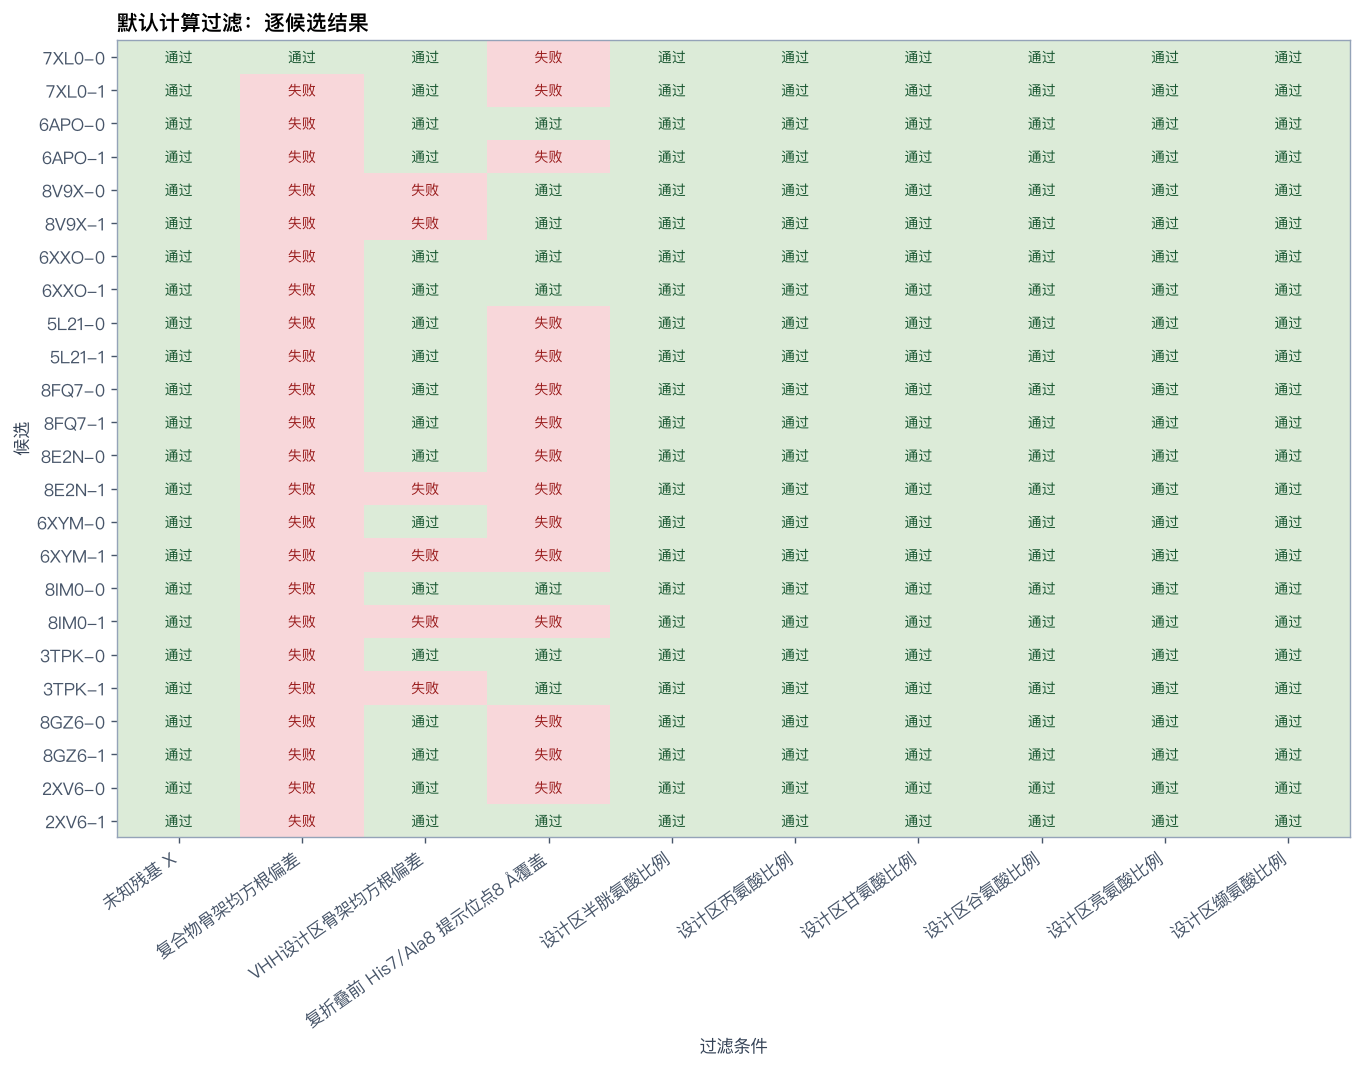

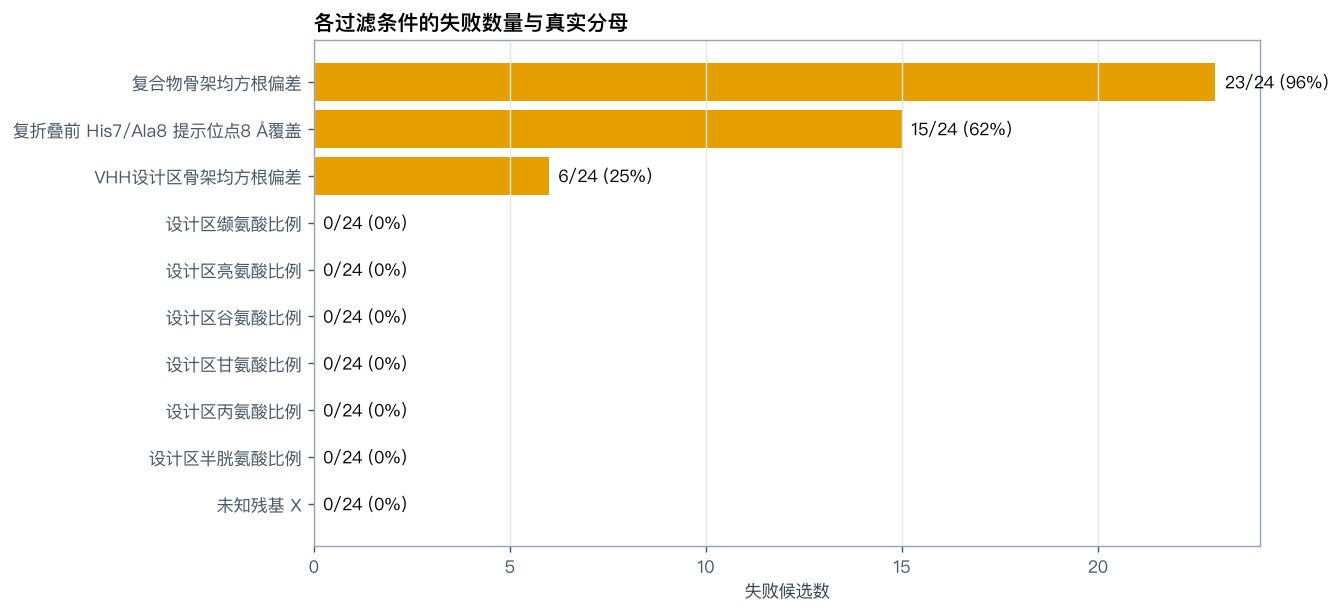

In [7]:
# 候选顺序来自候选规范表；过滤条件顺序来自 filter_order，均不手工指定数量。
ordered_candidates = candidate_metrics.sort_values(
    ["scaffold_selection_rank", "local_candidate_index"]
).copy()
candidate_order = ordered_candidates["candidate_id"].astype(str).tolist()
candidate_label_map = dict(zip(ordered_candidates["candidate_id"], ordered_candidates["candidate_label"], strict=True))
filter_order_table = (
    filter_results[["filter_order", "filter_label_cn"]]
    .drop_duplicates()
    .sort_values("filter_order")
)
filter_labels = filter_order_table["filter_label_cn"].tolist()
filter_matrix = (
    filter_results.pivot(index="candidate_id", columns="filter_label_cn", values="passed")
    .reindex(index=candidate_order, columns=filter_labels)
)
assert not filter_matrix.isna().any().any(), "过滤矩阵存在缺失的候选×条件组合。"

matrix_height = max(6.5, 0.36 * len(candidate_order))
matrix_width = max(11.0, 0.9 * len(filter_labels))
fig, ax = plt.subplots(figsize=(matrix_width, matrix_height))
ax.imshow(
    filter_matrix.astype(int).to_numpy(),
    cmap=ListedColormap(["#F8D7DA", "#DCEBD8"]),
    vmin=0,
    vmax=1,
    aspect="auto",
)
ax.set_xticks(np.arange(len(filter_labels)), filter_labels, rotation=35, ha="right")
ax.set_yticks(
    np.arange(len(candidate_order)),
    [candidate_label_map[candidate_id] for candidate_id in candidate_order],
)
for row_index in range(filter_matrix.shape[0]):
    for column_index in range(filter_matrix.shape[1]):
        passed = bool(filter_matrix.iloc[row_index, column_index])
        ax.text(
            column_index, row_index, "通过" if passed else "失败",
            ha="center", va="center", fontsize=8,
            color="#14532D" if passed else "#991B1B",
        )
ax.set_title("默认计算过滤：逐候选结果", loc="left")
ax.set_xlabel("过滤条件")
ax.set_ylabel("候选")
plt.tight_layout()
plt.show()

ordered_failures = filter_summary.sort_values(["failed_count", "filter_order"], ascending=[True, True])
fig, ax = plt.subplots(figsize=(10.8, max(5.0, 0.48 * len(ordered_failures))))
bars = ax.barh(ordered_failures["filter_label_cn"], ordered_failures["failed_count"], color="#E69F00")
ax.set_xlabel("失败候选数")
ax.set_title("各过滤条件的失败数量与真实分母", loc="left")
ax.grid(axis="x")
for bar, row in zip(bars, ordered_failures.itertuples(), strict=True):
    ax.text(
        row.failed_count + max(ordered_failures["candidate_count"].max() * 0.01, 0.05),
        bar.get_y() + bar.get_height()/2,
        f"{int(row.failed_count)}/{int(row.candidate_count)} ({row.failure_rate:.0%})",
        va="center",
    )
plt.tight_layout()
plt.show()

### 5. 结构自洽性：均方根偏差

- `filter_rmsd_a`：生成复合物与复折叠复合物的骨架自洽性。
- `filter_rmsd_design_a`：设计区自身对齐后的骨架自洽性。
- `bb_target_aligned_rmsd_design_a`：先对齐目标，再观察设计区相对位姿变化。

前两项的阈值从实际过滤表读取；第三项作为诊断量单独展示，不伪造成当前硬过滤条件。

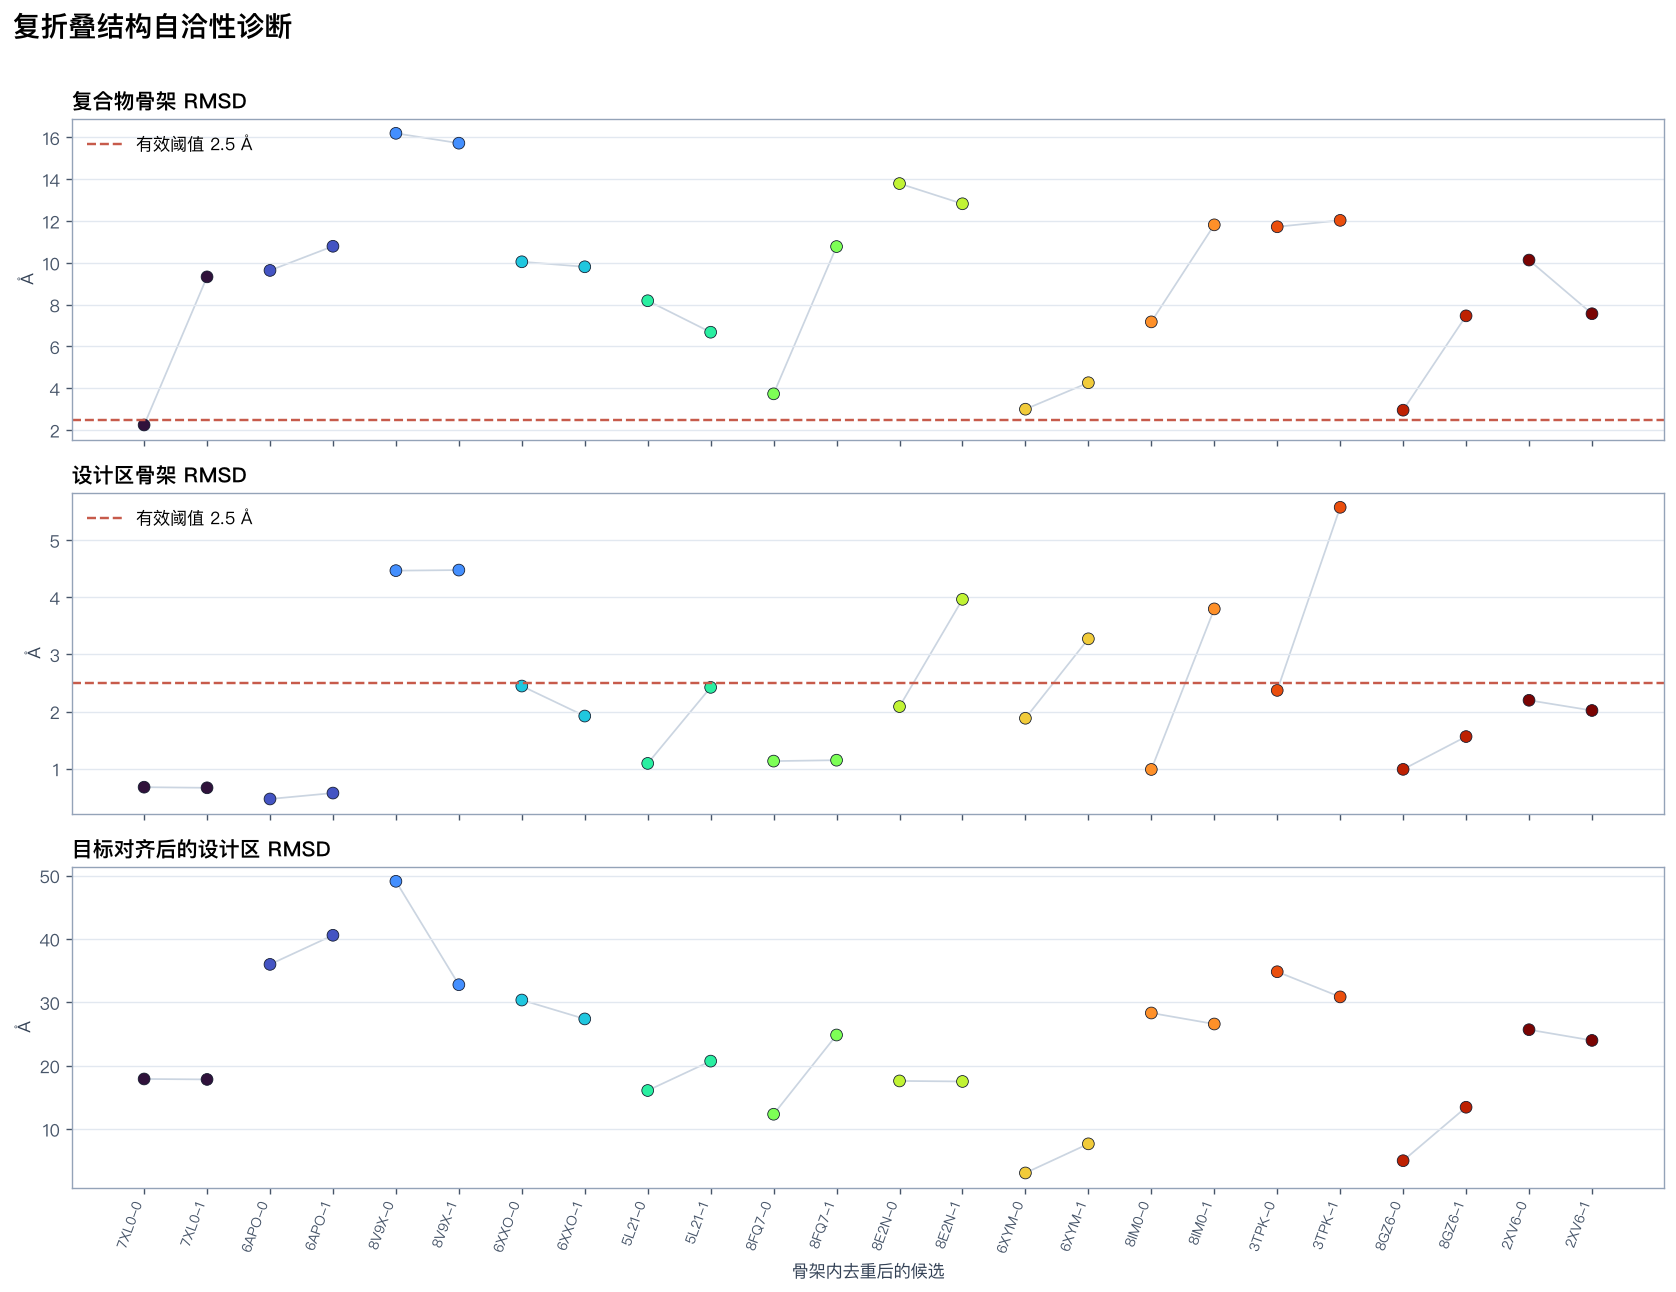

In [8]:
# 从过滤定义获取有效 RMSD 阈值，避免把版本默认值散落在图代码中。
rmsd_threshold_rows = (
    filter_results[filter_results["value_column"].isin(["filter_rmsd", "filter_rmsd_design"])]
    [["value_column", "threshold"]]
    .drop_duplicates()
)
rmsd_thresholds = dict(zip(rmsd_threshold_rows["value_column"], rmsd_threshold_rows["threshold"], strict=True))

rmsd_specs = [
    ("filter_rmsd_a", "复合物骨架 RMSD", rmsd_thresholds.get("filter_rmsd")),
    ("filter_rmsd_design_a", "设计区骨架 RMSD", rmsd_thresholds.get("filter_rmsd_design")),
    ("bb_target_aligned_rmsd_design_a", "目标对齐后的设计区 RMSD", None),
]
fig, axes = plt.subplots(len(rmsd_specs), 1, figsize=(13.5, 10.5), sharex=True)
x = np.arange(len(ordered_candidates))
labels = ordered_candidates["candidate_label"].astype(str).tolist()
colors = [scaffold_colors[scaffold_id] for scaffold_id in ordered_candidates["scaffold_id"]]

for ax, (column, title, threshold) in zip(axes, rmsd_specs, strict=True):
    # 同骨架候选之间用细线相连；每组有多少候选完全由表格决定。
    for _, group in ordered_candidates.groupby("scaffold_id", sort=False):
        positions = [ordered_candidates.index.get_loc(index) for index in group.index]
        ax.plot(positions, group[column], color="#CBD5E1", linewidth=1.0, zorder=1)
    ax.scatter(x, ordered_candidates[column], c=colors, s=46, edgecolor="#0F172A", linewidth=0.45, zorder=2)
    if threshold is not None and math.isfinite(float(threshold)):
        ax.axhline(float(threshold), color="#C75B4B", linestyle="--", linewidth=1.4, label=f"有效阈值 {float(threshold):g} Å")
        ax.legend(frameon=False, loc="upper left")
    ax.set_ylabel("Å")
    ax.set_title(title, loc="left")
    ax.grid(axis="y")
axes[-1].set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
axes[-1].set_xlabel("骨架内去重后的候选")
fig.suptitle("复折叠结构自洽性诊断", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 6. 界面代理：不同量纲分开

0–1 范围的结构置信代理与 Å 单位的预测对齐误差分开绘制。Notebook 不把这些量拼成“结合分”，也不换算为平衡解离常数或结合概率。

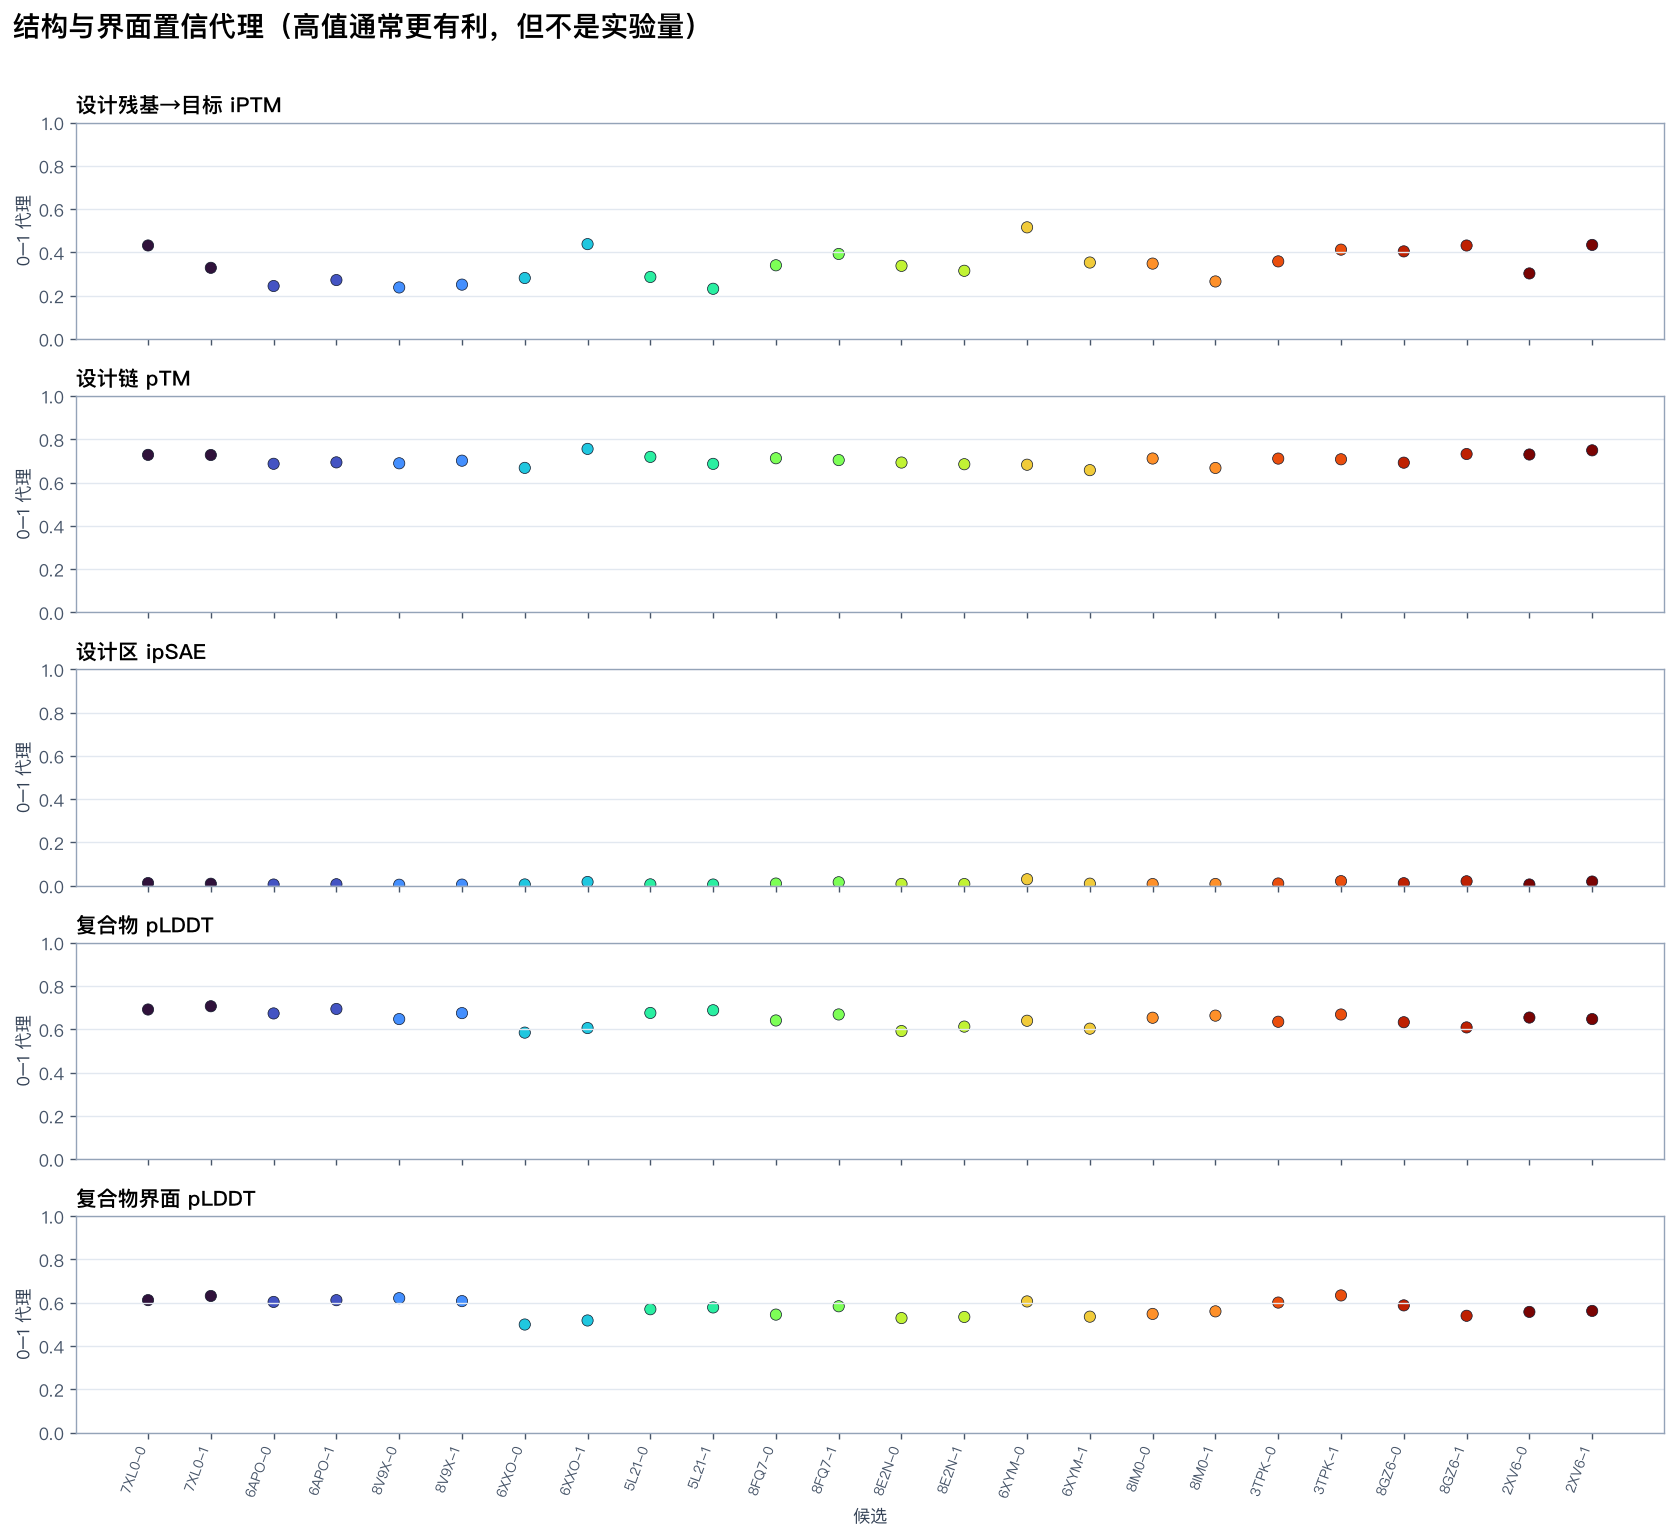

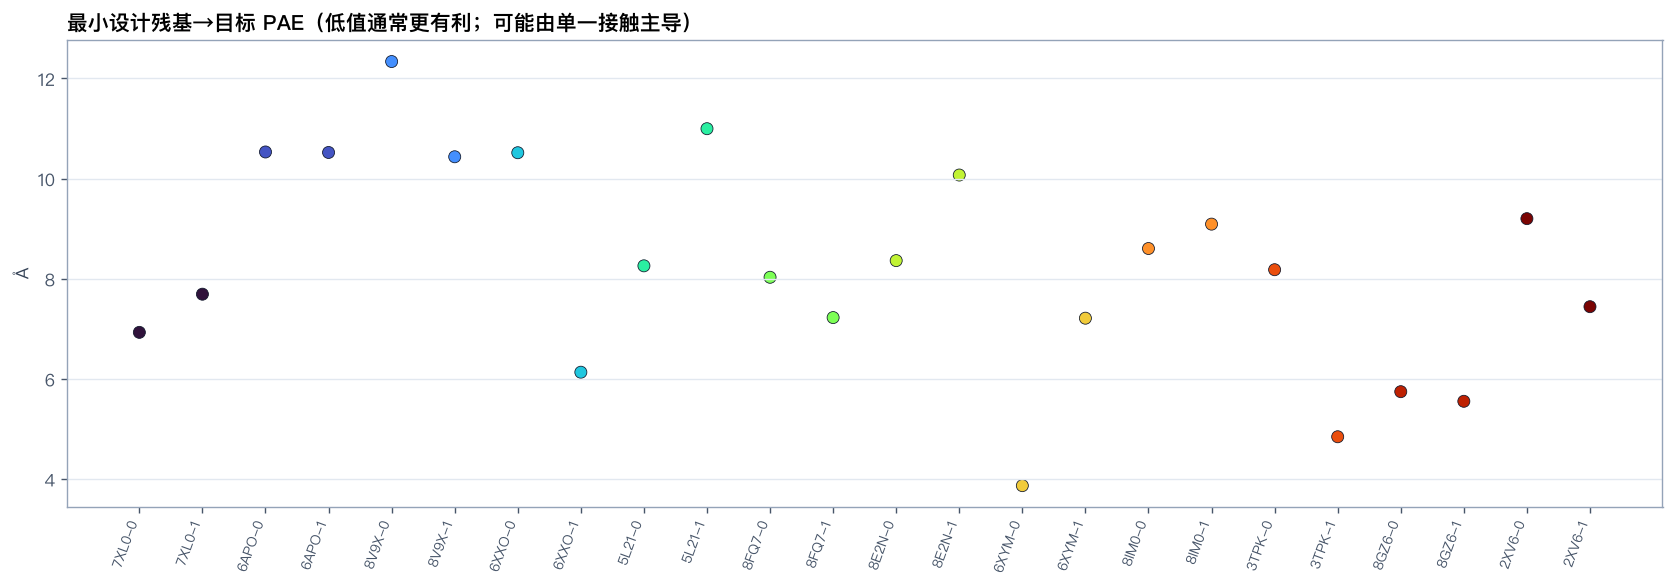

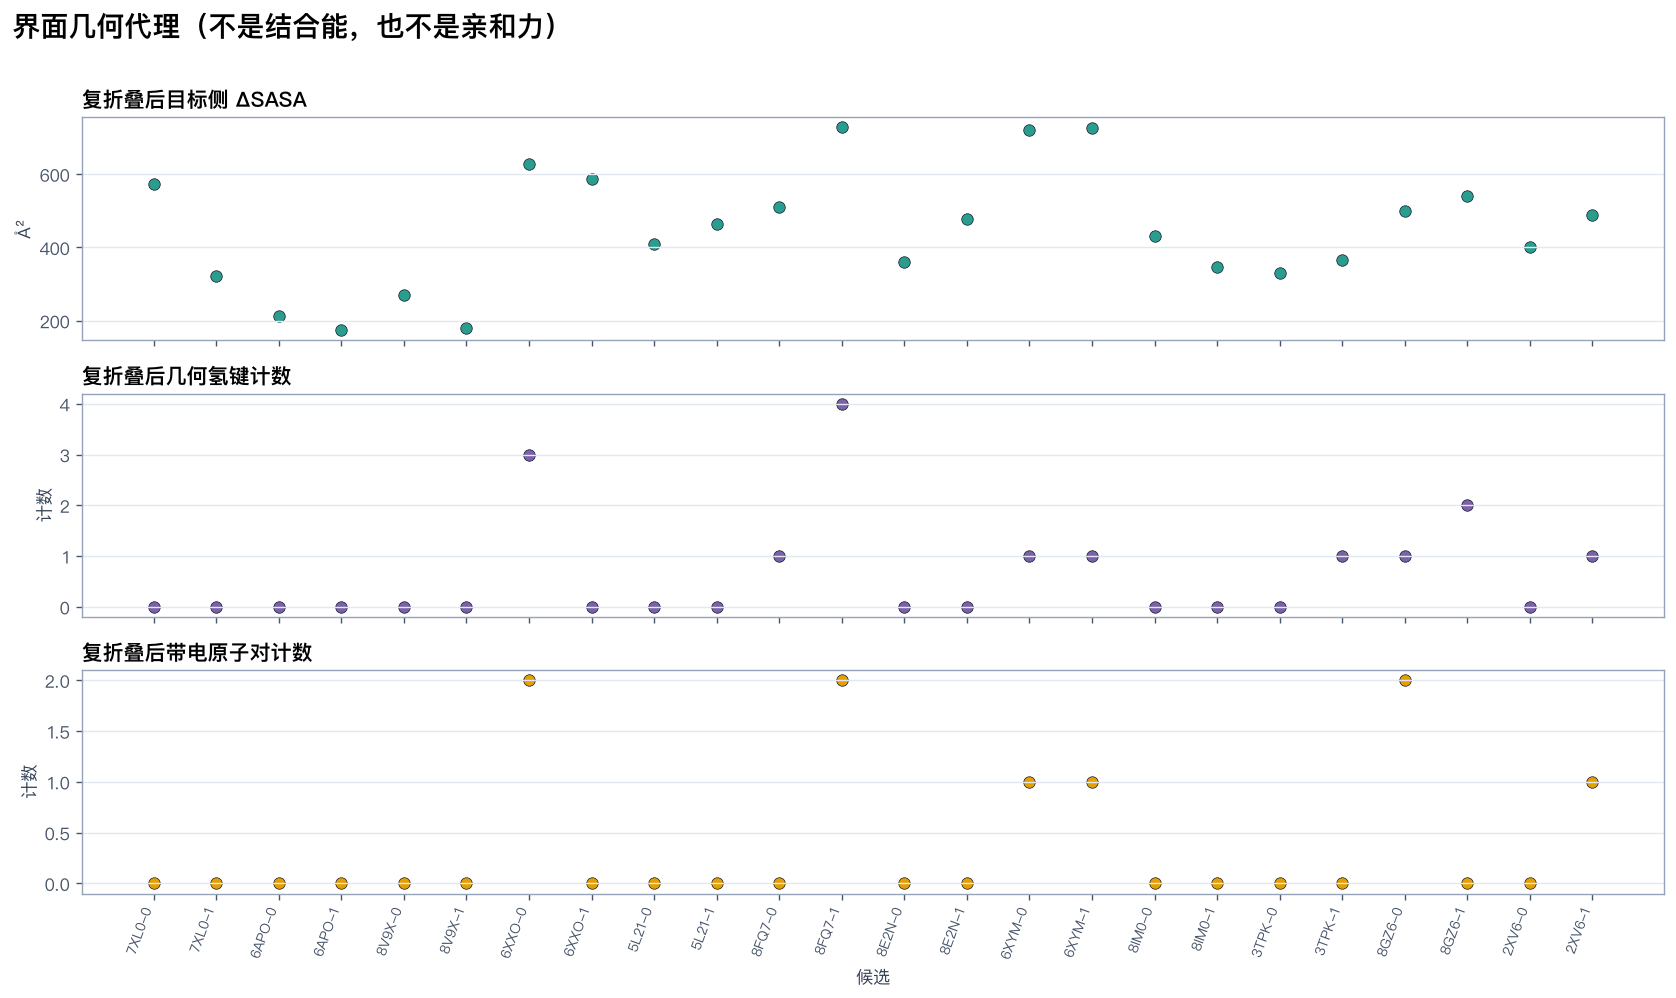

fold_out_npz没有完整二维PAE矩阵，因此报告不绘制PAE热图。


In [9]:
confidence_columns = [
    column for column in ["design_to_target_iptm", "design_ptm", "design_ipsae_min", "complex_plddt", "complex_iplddt"]
    if column in ordered_candidates.columns and ordered_candidates[column].notna().any()
]
confidence_labels = {
    "design_to_target_iptm": "设计残基→目标 iPTM",
    "design_ptm": "设计链 pTM",
    "design_ipsae_min": "设计区 ipSAE",
    "complex_plddt": "复合物 pLDDT",
    "complex_iplddt": "复合物界面 pLDDT",
}
fig, axes = plt.subplots(
    len(confidence_columns), 1,
    figsize=(13.5, max(4.5, 2.5 * len(confidence_columns))),
    sharex=True,
    squeeze=False,
)
for ax, column in zip(axes[:, 0], confidence_columns, strict=True):
    ax.scatter(x, ordered_candidates[column], c=colors, s=42, edgecolor="#0F172A", linewidth=0.4)
    ax.set_ylabel("0–1 代理")
    ax.set_ylim(0, max(1.0, float(ordered_candidates[column].max()) * 1.08))
    ax.set_title(confidence_labels[column], loc="left")
    ax.grid(axis="y")
axes[-1, 0].set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
axes[-1, 0].set_xlabel("候选")
fig.suptitle("结构与界面置信代理（高值通常更有利，但不是实验量）", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# PAE 只展示规范表中的汇总标量；NPZ 没有完整二维矩阵，因此不绘制 PAE 热图。
fig, ax = plt.subplots(figsize=(13.5, 4.8))
ax.scatter(x, ordered_candidates["min_design_to_target_pae_a"], c=colors, s=48, edgecolor="#0F172A", linewidth=0.45)
ax.set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
ax.set_ylabel("Å")
ax.set_title("最小设计残基→目标 PAE（低值通常更有利；可能由单一接触主导）", loc="left")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

# 界面几何代理继续分面展示，避免把面积、氢键和带电原子对相加成无物理量纲的总分。
geometry_specs = [
    ("target_delta_sasa_refolded_a2", "复折叠后目标侧 ΔSASA", "Å²", "#2A9D8F"),
    ("geometric_hbond_count_refolded", "复折叠后几何氢键计数", "计数", "#7B61A8"),
    ("charged_atom_pair_count_refolded", "复折叠后带电原子对计数", "计数", "#E69F00"),
]
available_geometry = [spec for spec in geometry_specs if spec[0] in ordered_candidates.columns]
fig, axes = plt.subplots(
    len(available_geometry), 1,
    figsize=(13.5, max(4.8, 2.7 * len(available_geometry))),
    sharex=True,
    squeeze=False,
)
for ax, (column, title, unit, color) in zip(axes[:, 0], available_geometry, strict=True):
    ax.scatter(x, ordered_candidates[column], color=color, s=44, edgecolor="#0F172A", linewidth=0.4)
    ax.set_ylabel(unit)
    ax.set_title(title, loc="left")
    ax.grid(axis="y")
axes[-1, 0].set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
axes[-1, 0].set_xlabel("候选")
fig.suptitle("界面几何代理（不是结合能，也不是亲和力）", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

pae_limit_text = str(npz_schema.get("important_limit", ""))
assert "没有完整二维PAE矩阵" in pae_limit_text and "不绘制PAE热图" in pae_limit_text, (
    "NPZ schema 没有明确记录二维 PAE 矩阵缺失及禁止绘图的限制。"
)
print(pae_limit_text)

### 7. His7 / Ala8 独立距离核验

这里有两个不同结构阶段，必须分开解释：

1. `prerefold_hotspot_coverage_fraction_lt8a`：逆折叠后、复折叠前结构的 BoltzGen token-center 覆盖比例；它参与本轮官方过滤。
2. `interface_contacts_independent.csv`：复折叠后 CIF 上独立计算的几何距离，包括：

- 热点残基到所有设计残基的最小重原子距离；
- 热点残基到所有设计残基的最小 Cα 距离。

两者不是同一个阶段、也不是同一种几何定义。本节并列展示它们是为了检查“复折叠前的提示位点信号在复折叠后是否仍有独立几何支持”，不会要求数值逐点相等，也不能把覆盖比例强转成整数“接触数”。

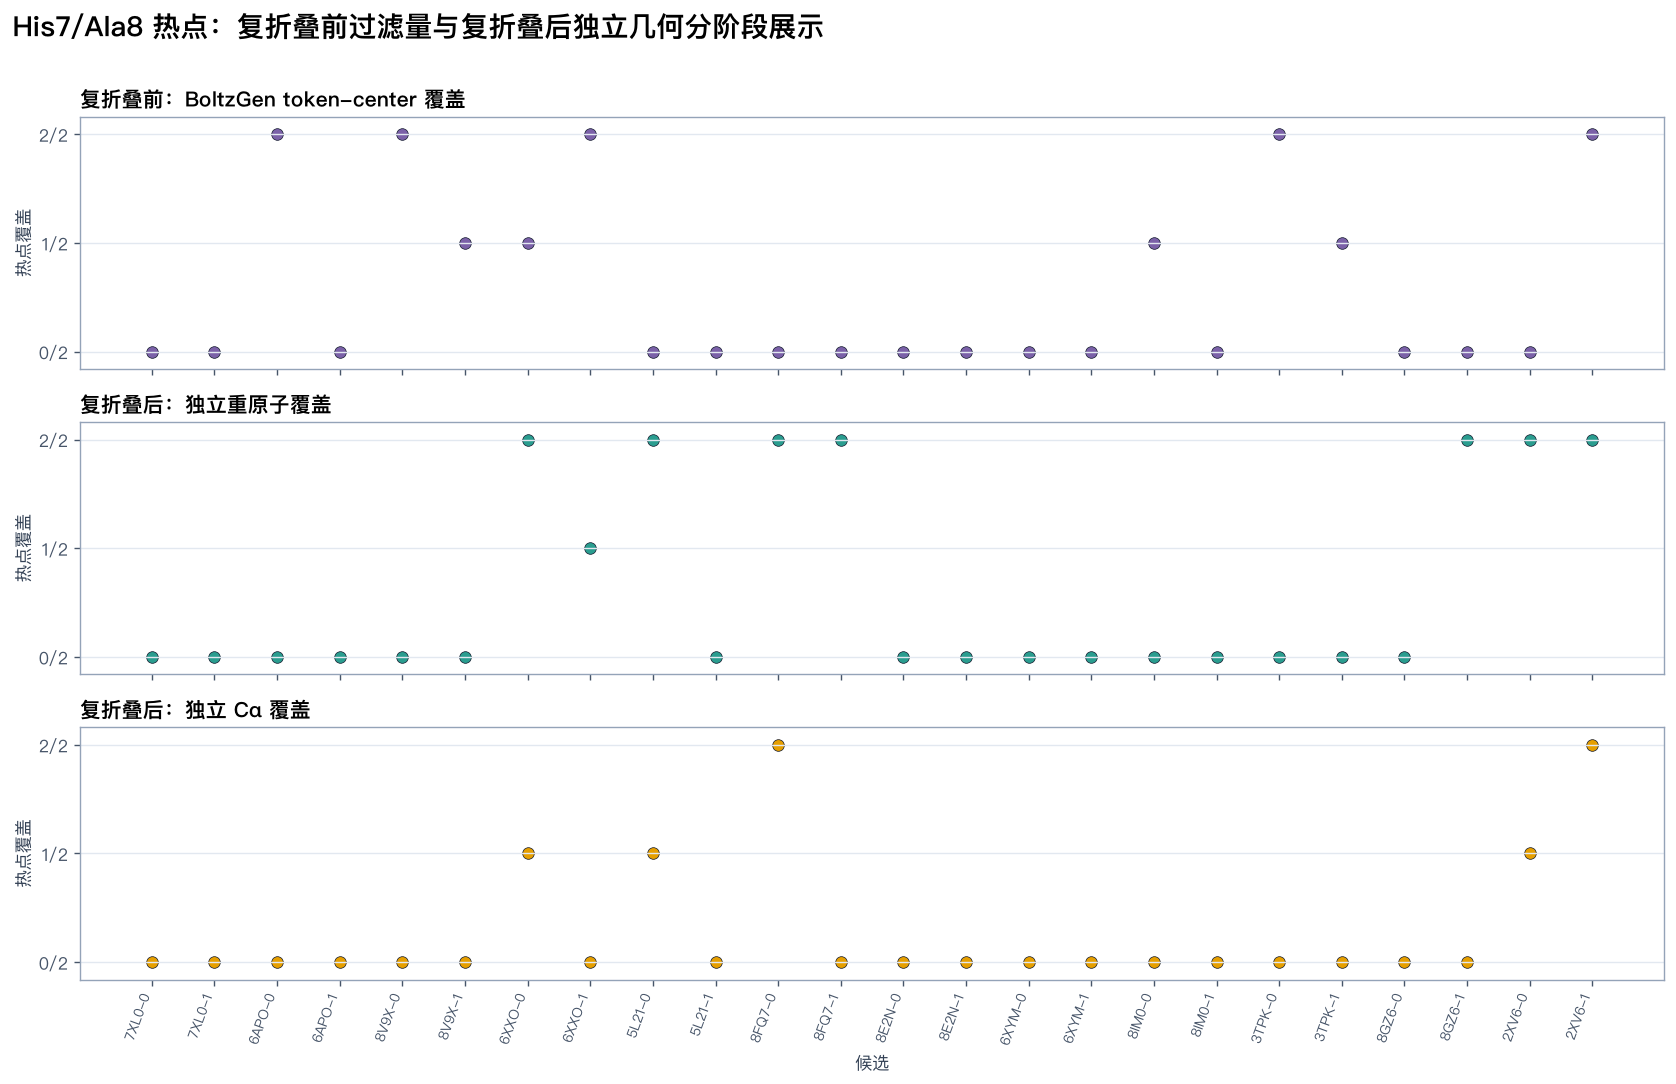

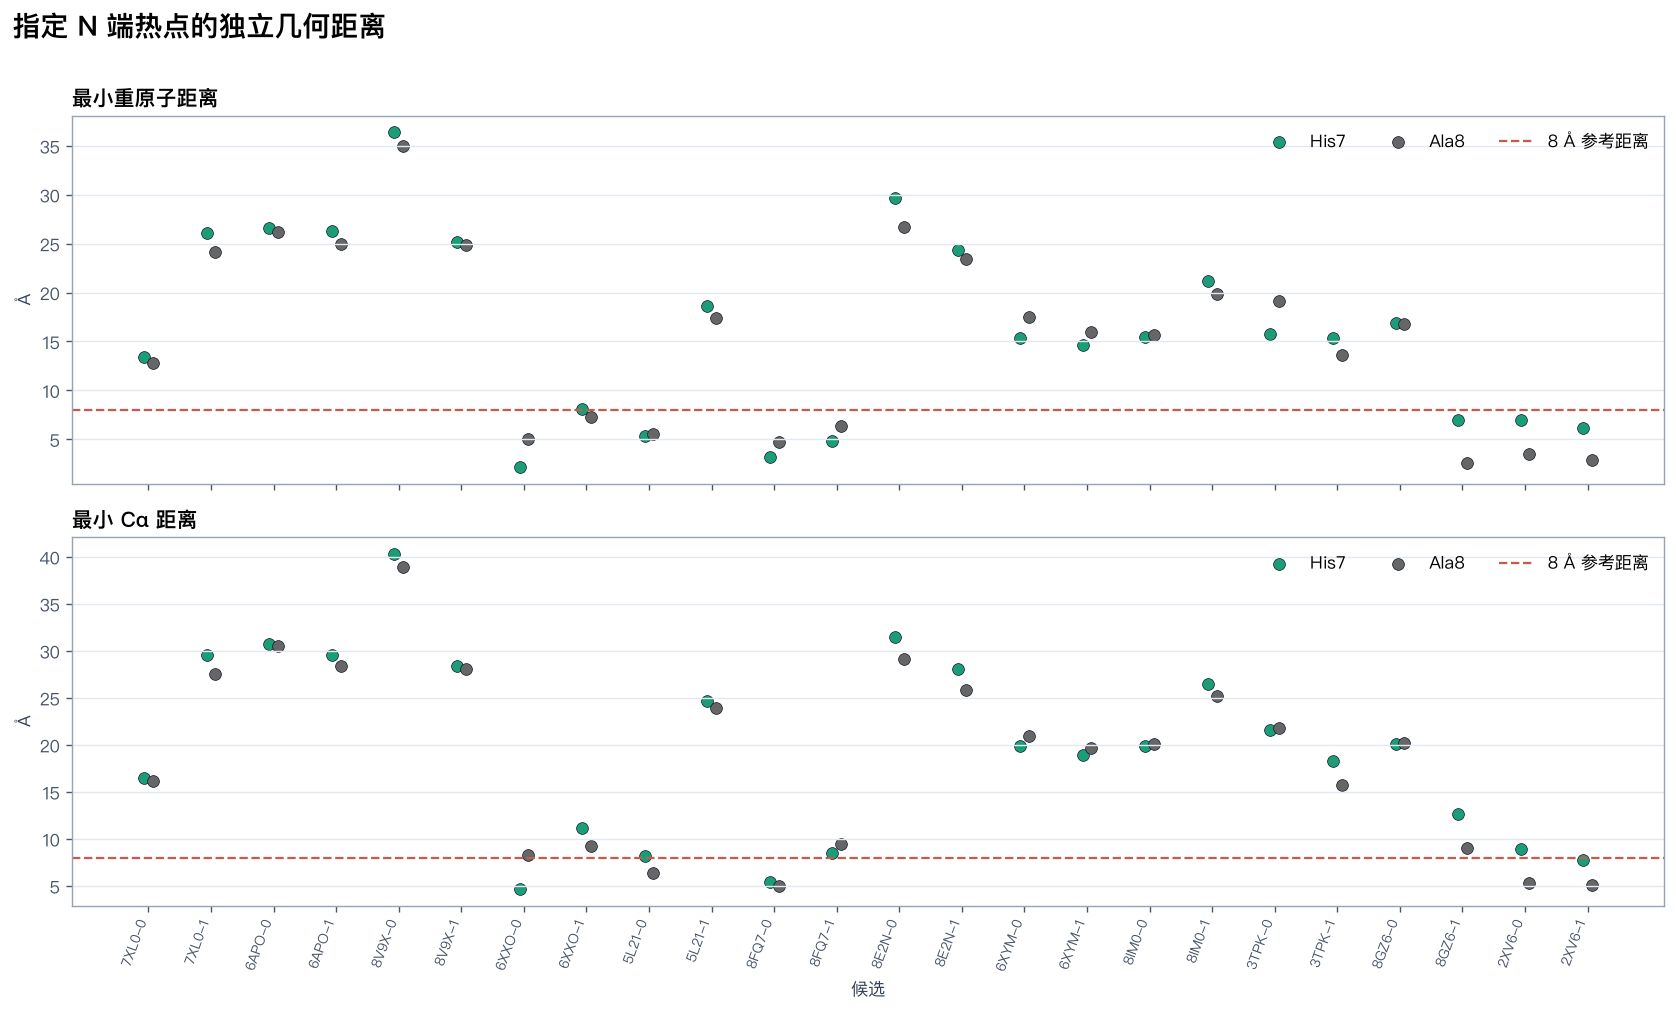

候选,复折叠前token-center覆盖,复折叠后独立重原子覆盖,复折叠后独立Cα覆盖,His7重原子最短 Å,Ala8重原子最短 Å
7XL0-0,0.000,0.000,0.000,13.460,12.828
7XL0-1,0.000,0.000,0.000,26.112,24.126
6APO-0,1.000,0.000,0.000,26.561,26.175
6APO-1,0.000,0.000,0.000,26.305,24.964
8V9X-0,1.000,0.000,0.000,36.385,35.026
8V9X-1,0.500,0.000,0.000,25.202,24.830
6XXO-0,0.500,1.000,0.500,2.138,4.992
6XXO-1,1.000,0.500,0.000,8.064,7.287
5L21-0,0.000,1.000,0.500,5.301,5.571
5L21-1,0.000,0.000,0.000,18.623,17.436


In [10]:
hotspot_names = input_manifest["target"]["binding_hint_biological_identity"]
observed_hotspots = set(interface_contacts["hotspot_biological_name"].astype(str))
assert set(hotspot_names) == observed_hotspots, (
    f"独立接触表热点与 provenance 不一致：清单={hotspot_names}，表={sorted(observed_hotspots)}"
)

contact_ordered = interface_contacts.copy()
contact_ordered["candidate_order"] = pd.Categorical(
    contact_ordered["candidate_id"], categories=candidate_order, ordered=True
)
contact_ordered = contact_ordered.sort_values(["candidate_order", "hotspot_label_seq_id"])

# 第一张图按阶段拆成两个面板；共享纵轴只因为两边都是 0/0.5/1 的覆盖比例，
# 标题和标签明确指出左边是复折叠前 token-center，右边是复折叠后独立几何。
phase_specs = [
    (
        "prerefold_hotspot_coverage_fraction_lt8a",
        "复折叠前：BoltzGen token-center 覆盖",
        "#7B61A8",
    ),
    (
        "independent_hotspot_coverage_heavy_lt8a",
        "复折叠后：独立重原子覆盖",
        "#2A9D8F",
    ),
    (
        "independent_hotspot_coverage_ca_lt8a",
        "复折叠后：独立 Cα 覆盖",
        "#E69F00",
    ),
]
fig, axes = plt.subplots(len(phase_specs), 1, figsize=(13.5, 8.8), sharex=True)
for ax, (column, title, color) in zip(axes, phase_specs, strict=True):
    ax.scatter(x, ordered_candidates[column], color=color, s=45, edgecolor="#0F172A", linewidth=0.4)
    ax.set_yticks([0.0, 0.5, 1.0], ["0/2", "1/2", "2/2"])
    ax.set_ylim(-0.08, 1.08)
    ax.set_ylabel("热点覆盖")
    ax.set_title(title, loc="left")
    ax.grid(axis="y")
axes[-1].set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
axes[-1].set_xlabel("候选")
fig.suptitle("His7/Ala8 热点：复折叠前过滤量与复折叠后独立几何分阶段展示", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

hotspot_color_map = {
    name: plt.get_cmap("Dark2", max(len(hotspot_names), 1))(index)
    for index, name in enumerate(hotspot_names)
}
distance_specs = [
    ("min_heavy_atom_distance_a", "最小重原子距离"),
    ("min_ca_distance_a", "最小 Cα 距离"),
]
fig, axes = plt.subplots(len(distance_specs), 1, figsize=(13.5, 8.2), sharex=True)
for ax, (column, title) in zip(axes, distance_specs, strict=True):
    for offset_index, hotspot in enumerate(hotspot_names):
        subset = contact_ordered[contact_ordered["hotspot_biological_name"] == hotspot].set_index("candidate_id").reindex(candidate_order)
        offset = (offset_index - (len(hotspot_names) - 1) / 2) * 0.14
        ax.scatter(
            x + offset, subset[column], label=hotspot,
            color=hotspot_color_map[hotspot], s=46, edgecolor="#0F172A", linewidth=0.4,
        )
    ax.axhline(8.0, color="#C75B4B", linestyle="--", linewidth=1.3, label="8 Å 参考距离")
    ax.set_ylabel("Å")
    ax.set_title(title, loc="left")
    ax.grid(axis="y")
    handles, legend_labels = ax.get_legend_handles_labels()
    # 保留唯一图例项，避免两个热点面板重复叠加相同标签。
    unique_legend = dict(zip(legend_labels, handles, strict=True))
    ax.legend(unique_legend.values(), unique_legend.keys(), frameon=False, ncol=max(1, len(unique_legend)))
axes[-1].set_xticks(x, labels, rotation=70, ha="right", fontsize=8)
axes[-1].set_xlabel("候选")
fig.suptitle("指定 N 端热点的独立几何距离", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

coverage_view = ordered_candidates[
    [
        "candidate_label",
        "prerefold_hotspot_coverage_fraction_lt8a",
        "independent_hotspot_coverage_heavy_lt8a",
        "independent_hotspot_coverage_ca_lt8a",
        "his7_min_heavy_atom_distance_a",
        "ala8_min_heavy_atom_distance_a",
    ]
].copy()
display(
    coverage_view.rename(
        columns={
            "candidate_label": "候选",
            "prerefold_hotspot_coverage_fraction_lt8a": "复折叠前token-center覆盖",
            "independent_hotspot_coverage_heavy_lt8a": "复折叠后独立重原子覆盖",
            "independent_hotspot_coverage_ca_lt8a": "复折叠后独立Cα覆盖",
            "his7_min_heavy_atom_distance_a": "His7重原子最短 Å",
            "ala8_min_heavy_atom_distance_a": "Ala8重原子最短 Å",
        }
    ).style.hide(axis="index").format(precision=3)
)

### 8. 序列多样性

设计区、完整 VHH、框架和 CDR3 必须分开解释。完整链相似性通常会被框架主导；同骨架候选的差异则主要来自设计区。所有 identity 都是规范表中已定义的全局比对一致率，仅用于本批描述。

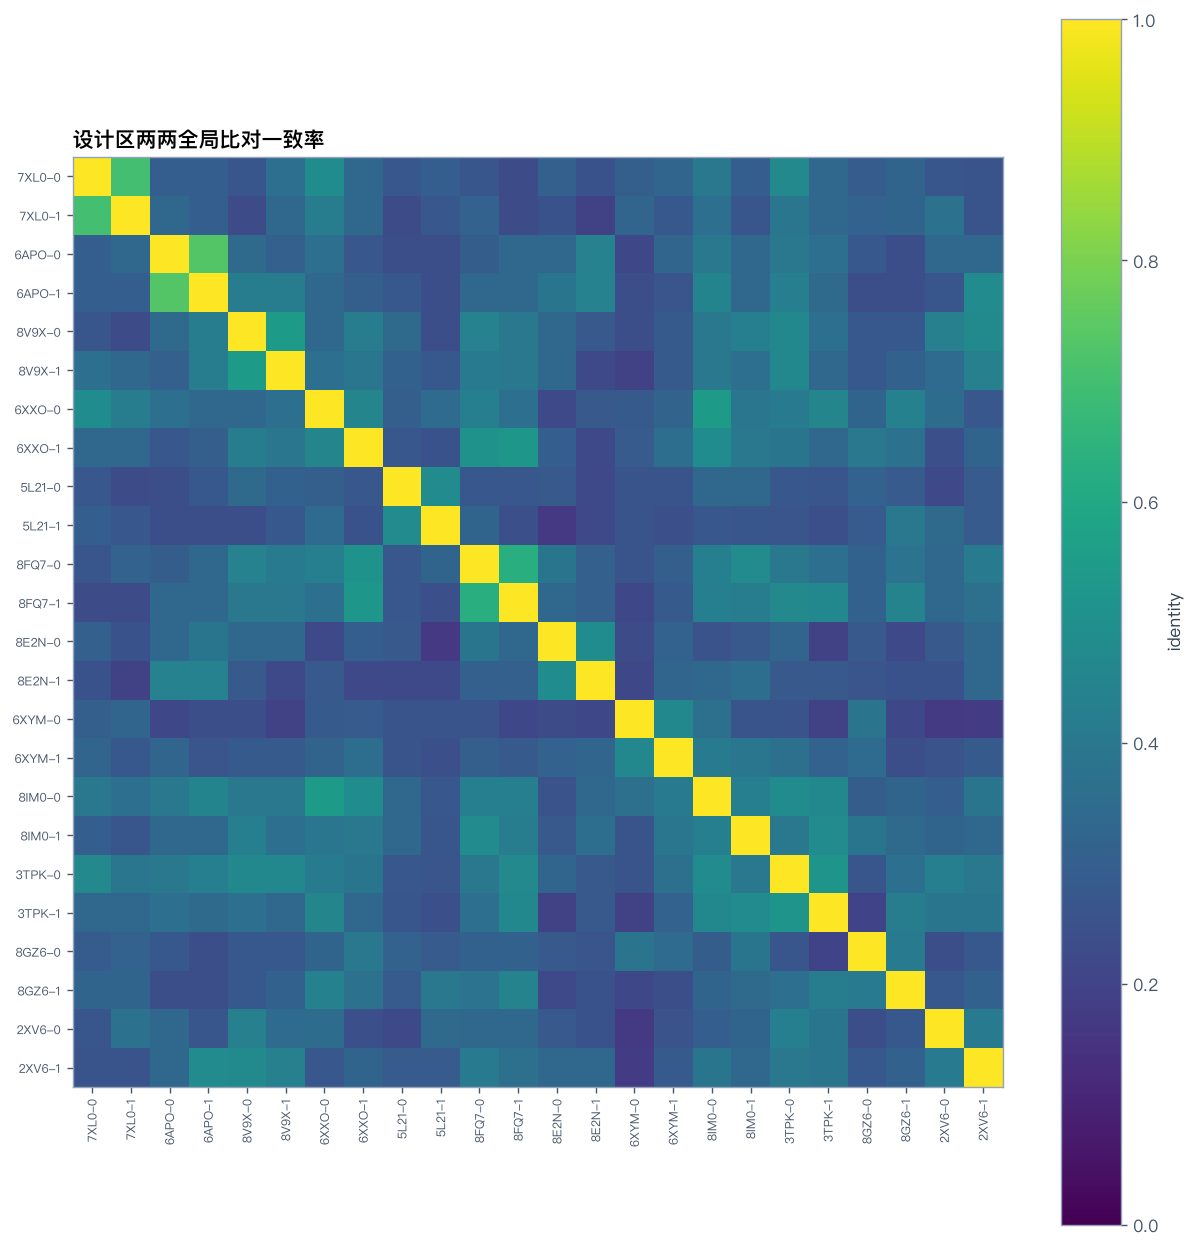

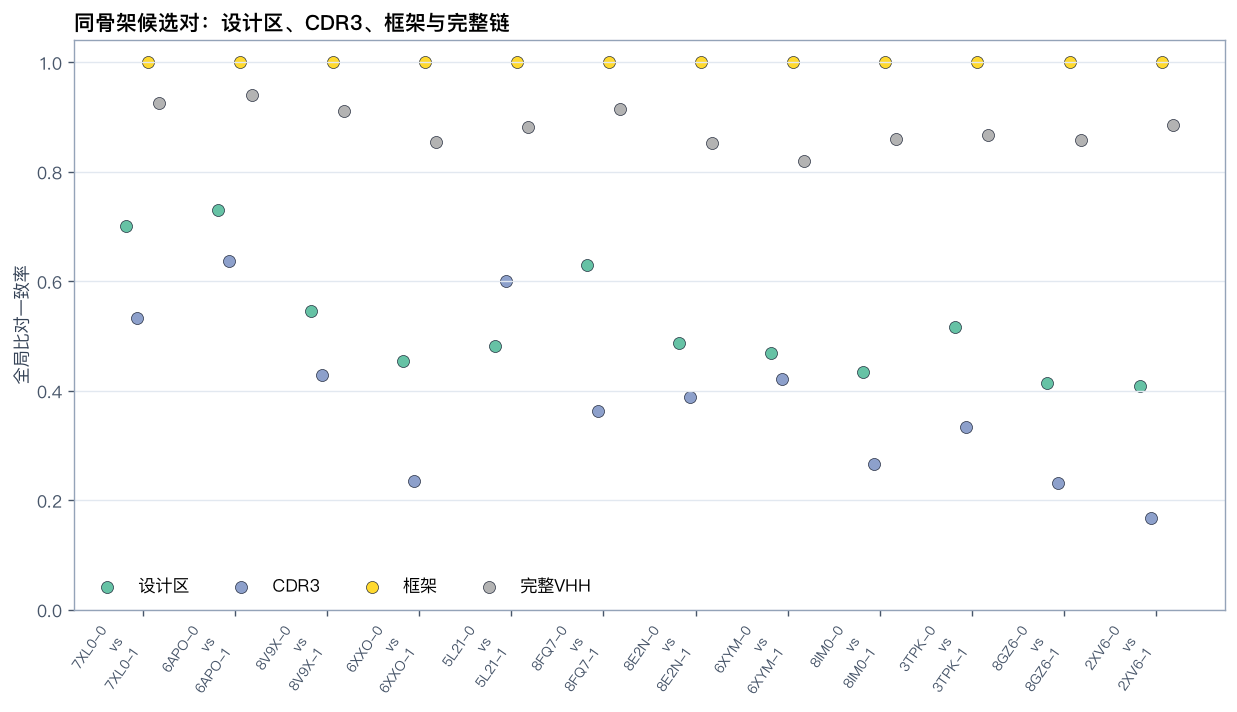

描述,数量
唯一完整VHH序列,24
唯一设计区序列,24
唯一CDR1序列,24
唯一CDR2序列,23
唯一CDR3序列,24
唯一框架序列,12


In [11]:
# 验证上三角（含对角线）组合数量；期望值由实际唯一候选数推导。
candidate_count = len(candidate_order)
expected_pair_rows = candidate_count * (candidate_count + 1) // 2
assert len(sequence_pairs) == expected_pair_rows, (
    f"序列对数量不完整：实际 {len(sequence_pairs)}，按 {candidate_count} 个候选应为 {expected_pair_rows}。"
)

pair_index = {candidate_id: index for index, candidate_id in enumerate(candidate_order)}
design_identity_matrix = np.eye(candidate_count, dtype=float)
for row in sequence_pairs.itertuples():
    left = pair_index[str(row.candidate_id_a)]
    right = pair_index[str(row.candidate_id_b)]
    value = float(row.design_sequence_identity)
    design_identity_matrix[left, right] = value
    design_identity_matrix[right, left] = value

heatmap_size = max(9.0, 0.42 * candidate_count)
fig, ax = plt.subplots(figsize=(heatmap_size, heatmap_size))
image = ax.imshow(design_identity_matrix, cmap="viridis", vmin=0, vmax=1, aspect="equal")
ax.set_xticks(np.arange(candidate_count), labels, rotation=90, fontsize=7)
ax.set_yticks(np.arange(candidate_count), labels, fontsize=7)
ax.set_title("设计区两两全局比对一致率", loc="left")
fig.colorbar(image, ax=ax, label="identity")
plt.tight_layout()
plt.show()

# 同骨架、非对角线序列对单独展示，避免跨框架差异掩盖每个骨架两次采样的关系。
within_scaffold_pairs = sequence_pairs[
    sequence_pairs["same_scaffold"]
    & (sequence_pairs["candidate_id_a"].astype(str) != sequence_pairs["candidate_id_b"].astype(str))
].copy()
identity_columns = [
    ("design_sequence_identity", "设计区"),
    ("cdr3_sequence_identity", "CDR3"),
    ("framework_sequence_identity", "框架"),
    ("full_vhh_sequence_identity", "完整VHH"),
]
if within_scaffold_pairs.empty:
    display(Markdown("没有同骨架的非对角线候选对：可能是每个骨架去重后只剩一个唯一候选。"))
else:
    x_pairs = np.arange(len(within_scaffold_pairs))
    fig, ax = plt.subplots(figsize=(max(10.0, 0.7 * len(within_scaffold_pairs)), 5.8))
    metric_colors = plt.get_cmap("Set2", len(identity_columns))
    for metric_index, (column, label) in enumerate(identity_columns):
        offset = (metric_index - (len(identity_columns) - 1) / 2) * 0.12
        ax.scatter(x_pairs + offset, within_scaffold_pairs[column], label=label, color=metric_colors(metric_index), s=48, edgecolor="#0F172A", linewidth=0.35)
    pair_labels = [
        # 使用通用 ASCII 字符，避免部分中文字体缺失双向箭头字形。
        f"{candidate_label_map[str(a)]}\nvs\n{candidate_label_map[str(b)]}"
        for a, b in zip(within_scaffold_pairs["candidate_id_a"], within_scaffold_pairs["candidate_id_b"], strict=True)
    ]
    ax.set_xticks(x_pairs, pair_labels, rotation=55, ha="right", fontsize=8)
    ax.set_ylim(0, 1.04)
    ax.set_ylabel("全局比对一致率")
    ax.set_title("同骨架候选对：设计区、CDR3、框架与完整链", loc="left")
    ax.legend(frameon=False, ncol=len(identity_columns))
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()

diversity_summary = pd.DataFrame(
    [
        ("唯一完整VHH序列", ordered_candidates["designed_chain_sequence"].nunique()),
        ("唯一设计区序列", ordered_candidates["designed_sequence"].nunique()),
        ("唯一CDR1序列", ordered_candidates["cdr1_sequence"].nunique()),
        ("唯一CDR2序列", ordered_candidates["cdr2_sequence"].nunique()),
        ("唯一CDR3序列", ordered_candidates["cdr3_sequence"].nunique()),
        ("唯一框架序列", ordered_candidates["framework_sequence"].nunique()),
    ],
    columns=["描述", "数量"],
)
display(diversity_summary.style.hide(axis="index"))

### 9. 耗时与运行资源

- 阶段耗时来自每个独立管线的状态 JSON 与执行日志汇总。
- RSS 是采样时进程树常驻内存之和，可能重复计算共享页。
- CPU 百分比可以超过 100%，因为进程树可同时使用多个核心。
- MPS 统一内存若没有稳定的进程级接口则标记“未测量”，不得用 checkpoint 文件大小替代。

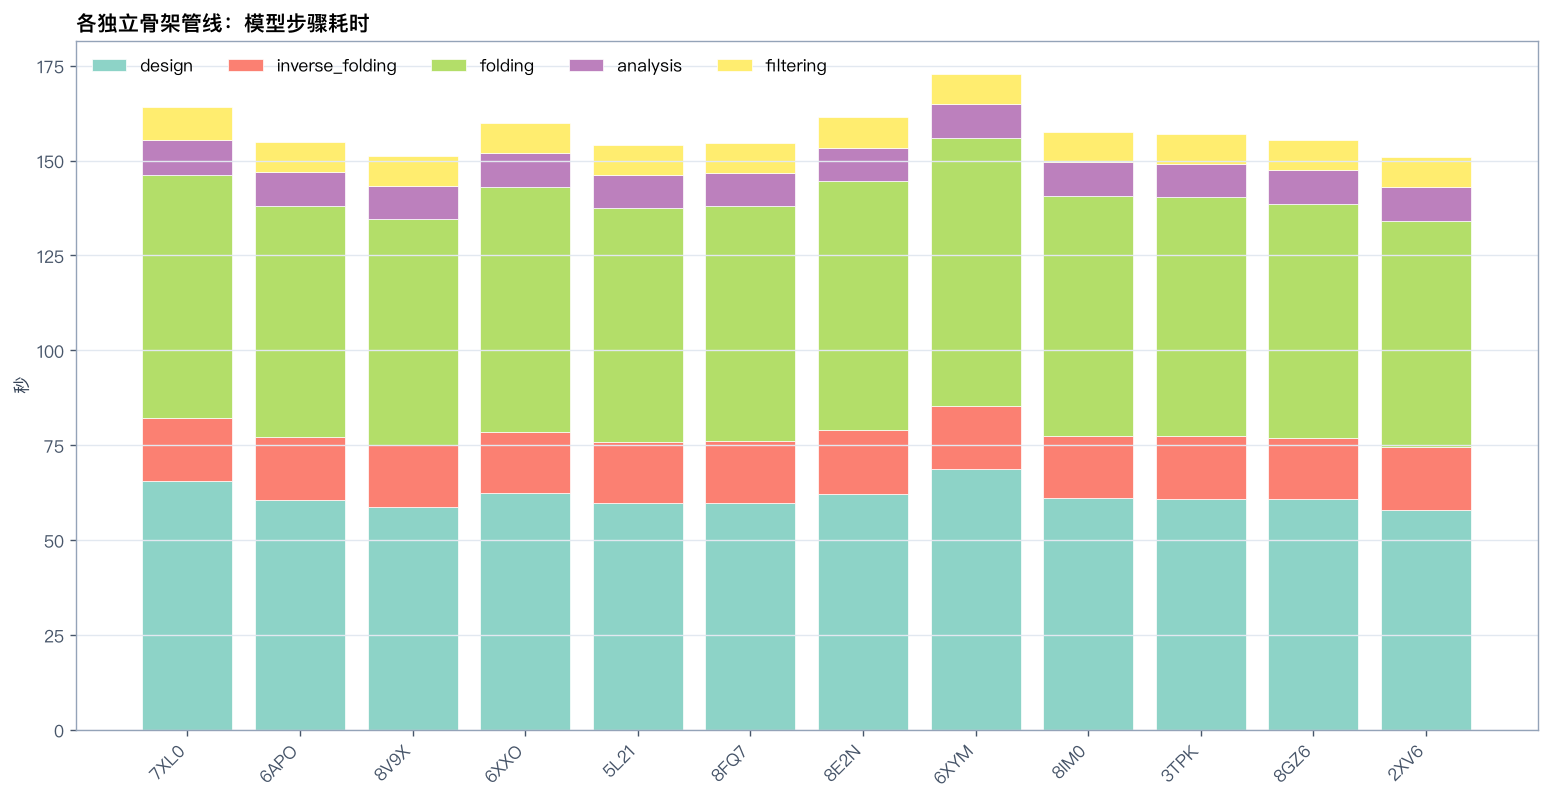

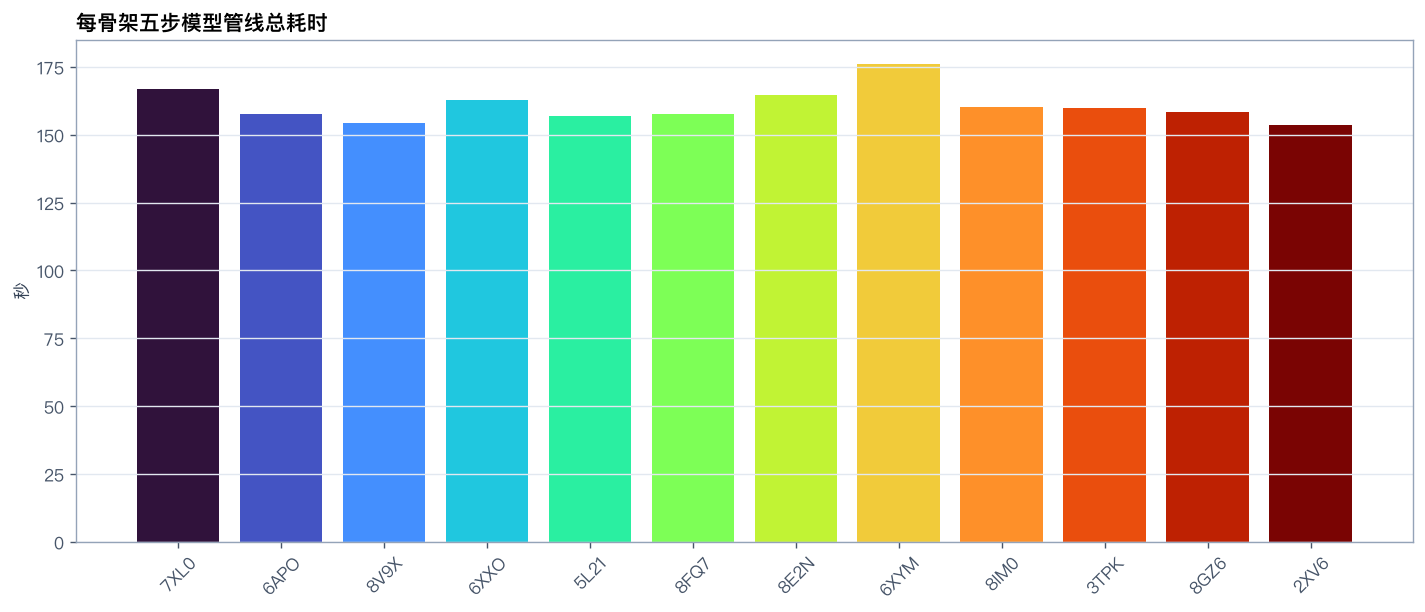

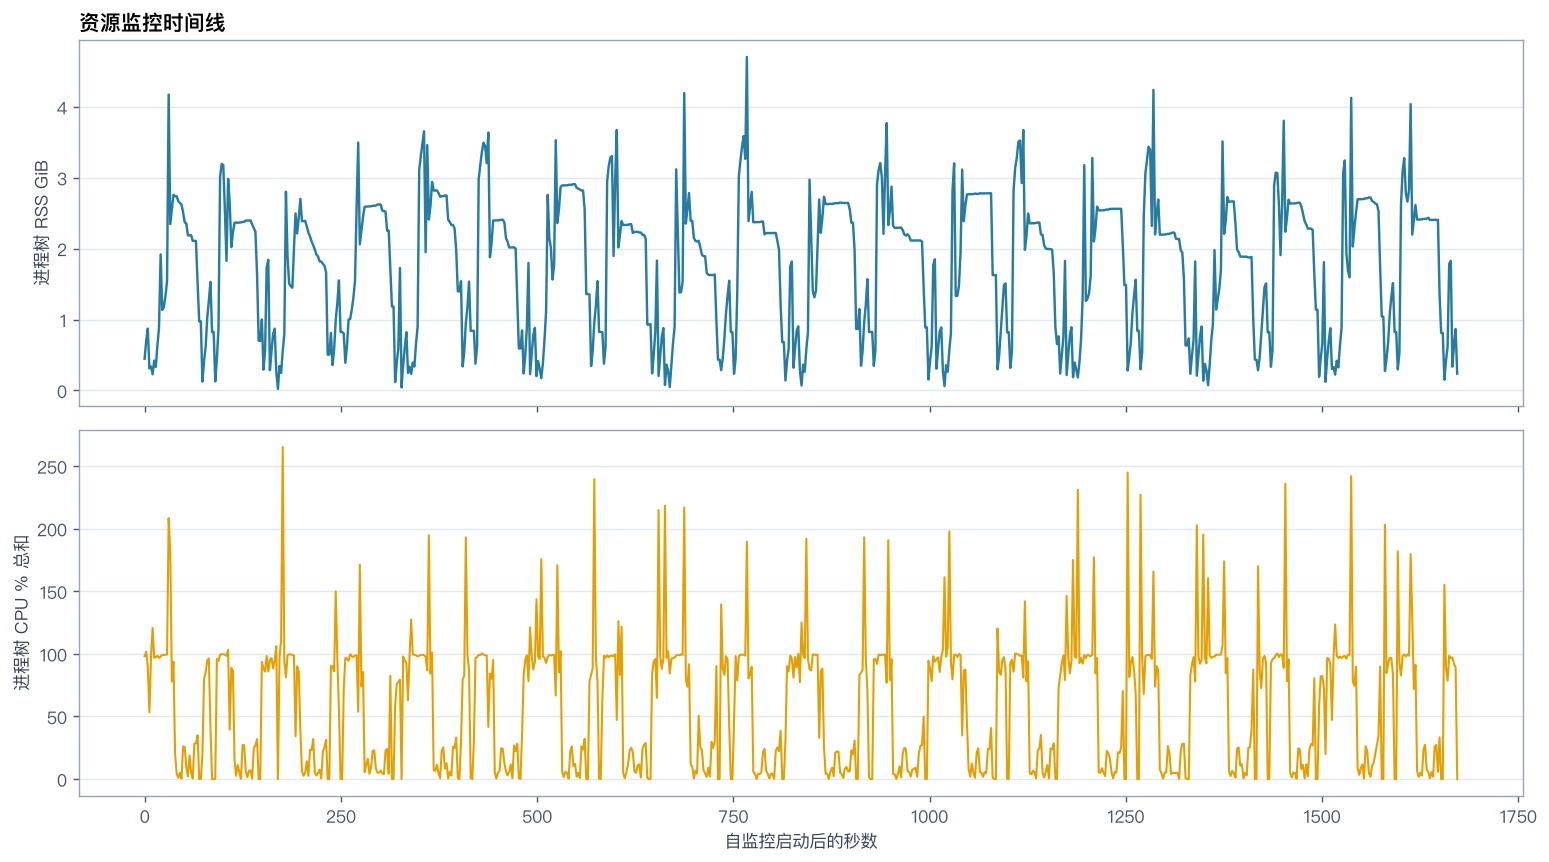

status,sample_count,sampling_interval_seconds,monitoring_duration_seconds,peak_process_tree_rss_gib,median_process_tree_rss_gib,peak_process_tree_cpu_percent_sum,note
partial_observed,818,2.000000,1672.236000,4.703659,2.026138,265.300000,监控从第2个骨架运行中途开始；RSS为进程树常驻内存，MPS统一内存未单独测量。


In [12]:
# 只绘制模型内部步骤；wrapper 的 check/configure/execute 总计另保留在规范表中。
model_stages = stage_timings[stage_timings["scope"] == "model_step"].copy()
stage_order_hint = ["design", "inverse_folding", "folding", "analysis", "filtering"]
observed_stages = model_stages["stage"].drop_duplicates().astype(str).tolist()
stage_order = [stage for stage in stage_order_hint if stage in observed_stages] + [
    stage for stage in observed_stages if stage not in stage_order_hint
]
stage_pivot = (
    model_stages.pivot_table(index="pdb_code", columns="stage", values="elapsed_seconds", aggfunc="sum")
    .reindex(index=run_manifest.sort_values("selection_rank")["pdb_code"].astype(str), columns=stage_order)
    .fillna(0.0)
)
fig, ax = plt.subplots(figsize=(12.5, 6.5))
bottom = np.zeros(len(stage_pivot))
stage_colors = plt.get_cmap("Set3", max(len(stage_order), 1))
for stage_index, stage in enumerate(stage_order):
    values = stage_pivot[stage].to_numpy(dtype=float)
    ax.bar(stage_pivot.index, values, bottom=bottom, label=stage, color=stage_colors(stage_index), edgecolor="white", linewidth=0.4)
    bottom += values
ax.set_ylabel("秒")
ax.set_title("各独立骨架管线：模型步骤耗时", loc="left")
# 同时设置刻度位置和标签，避免 Matplotlib 的 FixedFormatter 警告。
ax.set_xticks(np.arange(len(stage_pivot.index)), stage_pivot.index, rotation=45, ha="right")
ax.legend(frameon=False, ncol=max(1, min(len(stage_order), 5)))
ax.grid(axis="y")
plt.tight_layout()
plt.show()

execute_ordered = run_manifest.sort_values("selection_rank")
fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.bar(
    execute_ordered["pdb_code"], execute_ordered["execute_seconds"],
    color=[scaffold_colors[scaffold_id] for scaffold_id in execute_ordered["scaffold_id"]],
)
ax.set_ylabel("秒")
ax.set_title("每骨架五步模型管线总耗时", loc="left")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

if resource_samples.empty:
    display(Markdown("**资源时间序列：未测量。** 不从 checkpoint 或输出文件大小推断内存。"))
else:
    fig, axes = plt.subplots(2, 1, figsize=(12.5, 7.0), sharex=True)
    axes[0].plot(resource_samples["elapsed_seconds"], resource_samples["rss_gib_sum"], color="#277DA1", linewidth=1.4)
    axes[0].set_ylabel("进程树 RSS GiB")
    axes[0].set_title("资源监控时间线", loc="left")
    axes[0].grid(axis="y")
    axes[1].plot(resource_samples["elapsed_seconds"], resource_samples["cpu_percent_sum"], color="#E69F00", linewidth=1.2)
    axes[1].set_ylabel("进程树 CPU % 总和")
    axes[1].set_xlabel("自监控启动后的秒数")
    axes[1].grid(axis="y")
    plt.tight_layout()
    plt.show()

display(pd.DataFrame([resource_summary]).style.hide(axis="index"))

### 10. 候选详情

每个骨架和候选的详情默认折叠。点击后可查看序列、过滤失败、结构代理及可追溯产物。排序只用于复盘优先级，不等于亲和力或结合概率。

In [13]:
def format_number(value, digits=3, suffix=""):
    """将缺失值显示为“未测量”，有限数值按指定精度格式化。"""

    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return "未测量"
    if not math.isfinite(numeric):
        return "未测量"
    return f"{numeric:.{digits}f}{suffix}"


def local_artifact_link(relative_path: str, label: str) -> str:
    """把相对本轮根目录的谱系路径转换为相对 Notebook 的可点击链接。"""

    href = "../" + quote(str(relative_path), safe="/._-")
    return f'<a href="{href}">{html.escape(label)}</a>'


detail_blocks = []
for scaffold_id, scaffold_candidates in ordered_candidates.groupby("scaffold_id", sort=False):
    pdb_code = str(scaffold_candidates.iloc[0]["scaffold_pdb_code"])
    scaffold_survivors = int(scaffold_candidates["pass_all_default_filters"].sum())
    candidate_blocks = []
    for row in scaffold_candidates.itertuples():
        status_text = "通过全部默认计算过滤" if row.pass_all_default_filters else "未通过全部默认计算过滤"
        budget_text = "进入预算展示目录" if row.selected_by_budget else "未进入预算展示目录"
        lineage_subset = candidate_lineage[candidate_lineage["candidate_id"] == row.candidate_id]
        links = " · ".join(
            local_artifact_link(path, role)
            for role, path in zip(lineage_subset["artifact_role"], lineage_subset["path"], strict=True)
        )
        failed_text = html.escape(str(row.failed_filters_cn)) if str(row.failed_filters_cn).strip() else "无"
        candidate_blocks.append(
            f"""
            <details style="margin:10px 0;border:1px solid #CBD5E1;border-radius:10px;padding:10px 12px;background:#FFFFFF">
              <summary style="cursor:pointer;font-weight:700">{html.escape(str(row.candidate_label))}｜{status_text}｜{budget_text}</summary>
              <div style="margin-top:10px;line-height:1.65">
                <table style="border-collapse:collapse;width:100%">
                  <tr><th style="text-align:left">通过过滤</th><td>{int(row.computed_filter_pass_count)}/{int(row.computed_filter_total)}</td><th style="text-align:left">骨架内排名</th><td>{format_number(row.final_rank_within_scaffold, 0)}</td></tr>
                  <tr><th style="text-align:left">复合物RMSD</th><td>{format_number(row.filter_rmsd_a, 2, ' Å')}</td><th style="text-align:left">设计区RMSD</th><td>{format_number(row.filter_rmsd_design_a, 2, ' Å')}</td></tr>
                  <tr><th style="text-align:left">设计→目标 iPTM</th><td>{format_number(row.design_to_target_iptm, 3)}</td><th style="text-align:left">最小设计→目标 PAE</th><td>{format_number(row.min_design_to_target_pae_a, 2, ' Å')}</td></tr>
                  <tr><th style="text-align:left">复折叠前token-center覆盖</th><td>{format_number(row.prerefold_hotspot_coverage_fraction_lt8a, 2)}</td><th style="text-align:left">目标侧 ΔSASA</th><td>{format_number(row.target_delta_sasa_refolded_a2, 1, ' Å²')}</td></tr>
                </table>
                <p><b>失败条件：</b>{failed_text}</p>
                <p><b>CDR1：</b><code>{html.escape(str(row.cdr1_sequence))}</code><br>
                   <b>CDR2：</b><code>{html.escape(str(row.cdr2_sequence))}</code><br>
                   <b>CDR3：</b><code>{html.escape(str(row.cdr3_sequence))}</code></p>
                <p><b>完整 VHH：</b><br><code style="white-space:normal;word-break:break-all">{html.escape(str(row.designed_chain_sequence))}</code></p>
                <p><b>产物谱系：</b>{links}</p>
              </div>
            </details>
            """
        )
    detail_blocks.append(
        f"""
        <details style="margin:12px 0;border:2px solid #94A3B8;border-radius:12px;padding:12px 14px;background:#F8FAFC">
          <summary style="cursor:pointer;font-size:17px;font-weight:800">{html.escape(pdb_code)}｜唯一候选 {len(scaffold_candidates)}｜过滤幸存者 {scaffold_survivors}</summary>
          {''.join(candidate_blocks)}
        </details>
        """
    )

display(HTML("".join(detail_blocks)))

通过过滤,9/10,骨架内排名,1
复合物RMSD,2.24 Å,设计区RMSD,0.68 Å
设计→目标 iPTM,0.432,最小设计→目标 PAE,6.93 Å
复折叠前token-center覆盖,0.00,目标侧 ΔSASA,572.7 Å²
通过过滤,8/10,骨架内排名,2
复合物RMSD,9.33 Å,设计区RMSD,0.67 Å
设计→目标 iPTM,0.329,最小设计→目标 PAE,7.69 Å
复折叠前token-center覆盖,0.00,目标侧 ΔSASA,321.1 Å²
通过过滤,9/10,骨架内排名,2
复合物RMSD,9.64 Å,设计区RMSD,0.47 Å
设计→目标 iPTM,0.245,最小设计→目标 PAE,10.53 Å


## Takeaways

### 11. 限制与禁止结论

本轮只有单一 GLP-1(7–36) 正靶几何。以下内容无论候选分数如何，都不能从本 Notebook 得出：

- 平衡解离常数、抑制浓度、自由能、nM/µM 亲和力或结合概率；
- 已证实结合、实验命中或可用作捕获蛋白；
- GLP-1(7–36) 相对 GLP-1(9–36) 的型态选择性；
- C 端酰胺的原子级识别；
- 预算目录候选等于过滤合格；
- 从每骨架少量候选推断骨架因果效应、模型命中率或统计显著性；
- MPS 结果等同于官方 Linux + NVIDIA 基线；
- liability 规则代理等同于表达、稳定性、溶解性或免疫原性实验结果。

In [14]:
# 将 provenance 和 validation 中冻结的限制原样展示，避免手写摘要遗漏条件。
limitation_rows = []
for source, limitations in [
    ("input_manifest.known_limits", input_manifest.get("known_limits", [])),
    ("validation_report.scientific_caveats", validation_report.get("scientific_caveats", [])),
]:
    for limitation in limitations:
        limitation_rows.append({"来源": source, "限制": limitation})
display(pd.DataFrame(limitation_rows).style.hide(axis="index"))

来源,限制
input_manifest.known_limits,只使用一个 GLP-1 正靶几何，不评价 GLP-1(9-36) 或多构象鲁棒性
input_manifest.known_limits,C 端酰胺没有在当前标准聚合物 CIF 中完成原子级验证
input_manifest.known_limits,使用未合并的实验性 MPS 代码，不代表官方 v0.3.2 支持 macOS
input_manifest.known_limits,低采样步数和每候选单个复折叠样本适合首轮流程筛查，不适合最终定论
input_manifest.known_limits,结构置信度、界面几何和过滤状态都不是实验 Kd、亲和力或选择性
input_manifest.known_limits,BoltzGen CLI 没有为整条管线暴露统一随机种子，精确复现序列不保证
validation_report.scientific_caveats,本轮是预训练模型推理，不是模型权重训练。
validation_report.scientific_caveats,只有单一6X18受体结合态几何，没有GLP-1(9-36)或多构象反筛。
validation_report.scientific_caveats,目标C端酰胺未在当前标准聚合物CIF中完成原子级验证。
validation_report.scientific_caveats,iPTM、PAE、RMSD、SASA和接触数都是计算代理，不是Kd或实验命中。


### 12. 下一轮建议

下一轮动作要由实际幸存者数量决定：

- 若没有默认过滤幸存者：优先检查主要失败门槛、采样预算、热点约束和骨架适配，不通过放宽阈值包装“命中”。
- 若存在计算幸存者：先做独立模型复预测和 VHH 单体折叠，再决定是否进入更高预算。
- 任何选择性工作都必须对同一完整候选序列成对评估 GLP-1(7–36)、GLP-1(9–36) 和挑战构象，统一预测设置并保留成对差值。
- 在合成前增加框架二硫键、聚集/疏水风险、序列责任位点和结构界面人工检查。

In [15]:
# 根据真实过滤结果生成行动分支，不把“人工复盘优先级”写成 binder 排名。
if survivors == 0:
    leading_failures = filter_summary.sort_values(
        ["failed_count", "filter_order"], ascending=[False, True]
    ).head(min(3, len(filter_summary)))
    failure_lines = "\n".join(
        f"- {row.filter_label_cn}：{int(row.failed_count)}/{int(row.candidate_count)} 失败（{row.failure_rate:.0%}）"
        for row in leading_failures.itertuples()
    )
    action_text = f"""
    **本轮没有默认计算过滤幸存者。** 这不影响工程管线完成的事实，但本轮不产生合成短名单。

    主要失败条件：

    {failure_lines}

    下一轮应针对这些门槛定位原因并增加采样/修正输入；不能仅删除失败条件后把原候选改称合格。
    """
else:
    action_text = f"""
    **本轮有 {survivors} 个默认计算过滤幸存者。** 它们仍只是计算候选，不是实验命中。

    在任何合成决策前，必须从序列重新进行独立模型复预测、VHH 单体折叠和 GLP-1 正负靶成对重预测，并复核热点和界面是否跨模型一致。
    """
display(Markdown(action_text))


    **本轮没有默认计算过滤幸存者。** 这不影响工程管线完成的事实，但本轮不产生合成短名单。

    主要失败条件：

    - 复合物骨架均方根偏差：23/24 失败（96%）
- 复折叠前 His7/Ala8 提示位点8 Å覆盖：15/24 失败（62%）
- VHH设计区骨架均方根偏差：6/24 失败（25%）

    下一轮应针对这些门槛定位原因并增加采样/修正输入；不能仅删除失败条件后把原候选改称合格。
    

### 13. 可追溯来源

每个结论均可追踪到规范表或冻结 provenance。Notebook 本身不扫描 `runs/`，因此不会在复盘过程中意外改变或重新解释原始模型目录。

In [16]:
source_rows = []
for name, path in required_files.items():
    source_rows.append(
        {
            "逻辑名称": name,
            "相对路径": path.relative_to(RUN_ROOT).as_posix(),
            "大小 KiB": path.stat().st_size / 1024,
        }
    )
if optional_resource_samples.is_file():
    source_rows.append(
        {
            "逻辑名称": "runtime_resource_samples",
            "相对路径": optional_resource_samples.relative_to(RUN_ROOT).as_posix(),
            "大小 KiB": optional_resource_samples.stat().st_size / 1024,
        }
    )
display(
    pd.DataFrame(source_rows).style.hide(axis="index").format({"大小 KiB": "{:.1f}"})
)

print(f"分析生成时间（UTC）：{run_summary.get('generated_at_utc', '未记录')}")
print(f"验证时间（UTC）：{validation_report.get('validated_at_utc', '未记录')}")
print(f"结果分类：{run_summary.get('result_classification', '未记录')}")
print("Notebook 输入范围：analysis/ + provenance/；没有执行 BoltzGen 推理。")

逻辑名称,相对路径,大小 KiB
input_manifest,provenance/input_manifest.json,104.0
runtime_preflight,provenance/runtime_preflight.json,0.2
run_summary,analysis/run_summary.json,4.0
validation_report,analysis/validation_report.json,1.9
resource_summary,analysis/resource_summary.json,0.4
npz_schema,analysis/npz_schema.json,1207.6
run_manifest,analysis/run_manifest.csv,1.7
candidate_metrics,analysis/candidate_metrics.csv,26.5
process_funnel,analysis/process_funnel.csv,0.6
candidate_filter_results,analysis/candidate_filter_results.csv,31.9


分析生成时间（UTC）：2026-08-19T15:45:56.515184+00:00
验证时间（UTC）：2026-08-19T15:45:56.513833+00:00
结果分类：PIPELINE_COMPLETE_BUT_ZERO_DEFAULT_FILTER_SURVIVORS
Notebook 输入范围：analysis/ + provenance/；没有执行 BoltzGen 推理。
